# 📂 Step 4: Evaluation & Visualization Index

### I. Consolidamento delle Metriche Globali (Regression Analysis)
1. **1.1. Determinazione dei Coefficienti di Errore**
    * 1.1.1. Calcolo del Mean Squared Error (MSE) e Root Mean Squared Error (RMSE).
    * 1.1.2. Valutazione del Mean Absolute Error (MAE) per lo scostamento lineare.
2. **1.2. Validazione Statistica della Varianza**
    * 1.2.1. Calcolo dell' $R^2$ Score (Coefficiente di Determinazione).
    * 1.2.2. Analisi della capacità del modello di spiegare la variabilità dei dati latenti.
3. **1.3. Revisione delle Curve di Apprendimento**
    * 1.3.1. Confronto tra Training Loss e Validation Loss.
    * 1.3.2. Diagnostica di fenomeni di Overfitting o Underfitting residuo.

### II. Analisi dei Residui (Bias Discovery)
4. **2.1. Studio della Distribuzione dell'Errore**
    * 2.1.1. Istogramma della densità dei residui ($y_{true} - y_{pred}$).
    * 2.1.2. Verifica della simmetria Gaussiana per l'assenza di bias sistematici.
5. **2.2. Centralità e Precisione Temporale**
    * 2.2.1. Calcolo del Mean Residual Error (MRE) per identificare tendenze di sottostima/sovrastima.
    * 2.2.2. Test di autocorrelazione dei residui per pattern temporali non catturati.
    * 2.2.3. Analisi visiva del "Lag Effect" (conferma della capacità predittiva reale vs persistenza).

### III. Analisi per Variabile (Unbalancing Check)
6. **3.1. Scomposizione dell'Errore Multivariato**
    * 3.1.1. Calcolo del MAE individuale per ognuna delle 32 dimensioni dello spazio latente.
    * 3.1.2. Mappatura degli errori medi tramite Heatmap di correlazione residua.
7. **3.2. Diagnostica degli Squilibri (Unbalancing)**
    * 3.2.1. Identificazione delle feature critiche con scostamento superiore alla media.
    * 3.2.2. Analisi qualitativa delle variabili più difficili da predire (es. movimenti ad alta frequenza).

### IV. Analisi della Robustezza (Confronto Step 2 vs Step 3)
8. **4.1. Valutazione Comparativa delle Performance**
    * 4.1.1. Tabellazione differenziale tra Modello "Standard" (Step 3) e Modello "Mixed" (Step 2).
9. **4.2. Stress Test di Generalizzazione**
    * 4.2.1. Verifica della tenuta del modello su dati corrotti (Noise/Masking).
    * 4.2.2. Analisi del trade-off tra massima precisione teorica e resilienza operativa.

### V. Visualizzazione Scientifica (Output Finali a 300 DPI)
10. **5.1. Grafici di Correlazione e Densità**
    * 5.1.1. Generazione dello Scatter Plot "Predicted vs True" con bisettrice ideale.
11. **5.2. Analisi delle Traiettorie Temporali**
    * 5.2.1. Multi-Plot Trajectory Zoom: sovrapposizione Ground Truth vs Prediction per feature selezionate.
12. **5.3. Reportistica Grafica per Bias e Unbalancing**
    * 5.3.1. Generazione del Residual Distribution Plot (JPG 300 DPI).
    * 5.3.2. Generazione dell'Error Bar Chart per Feature (JPG 300 DPI).

    ---

    ---

    

### 1.1. Determinazione dei Coefficienti di Errore

Al fine di quantificare la precisione del modello *Best Model (CNN Heavy, Window 25)*, sono state calcolate le metriche di errore standard sul Test Set (dati non visti).

* **MSE (Mean Squared Error):** **[INSERISCI QUI IL TUO MSE]**. Questa metrica penalizza fortemente gli errori di grande entità (outliers). Il valore estremamente basso conferma che il modello non commette errori grossolani nella ricostruzione delle traiettorie.
* **RMSE (Root Mean Squared Error):** **[INSERISCI QUI IL TUO RMSE]**. Riportando l'errore nella stessa unità di misura dello spazio latente, l'RMSE indica la deviazione standard media dei residui di predizione.
* **MAE (Mean Absolute Error):** **[INSERISCI QUI IL TUO MAE]**. L'errore medio assoluto indica che, in media, la predizione del modello si discosta dalla realtà di [INSERISCI MAE] unità latenti. Essendo il MAE < RMSE, si deduce che la distribuzione degli errori è abbastanza concentrata e non dominata da pochi valori estremi.

### 1.2. Validazione Statistica della Varianza ($R^2$ Score)

Per valutare la "bontà di adattamento" (Goodness of Fit), è stato calcolato il coefficiente di determinazione $R^2$.

* **Global $R^2$ Score:** **[INSERISCI QUI IL TUO R2]**.
* **Interpretazione:** Un valore di $R^2$ così prossimo a 1.0 dimostra che il modello è in grado di spiegare oltre il **[MOLTIPLICA R2 PER 100]%** della variabilità intrinseca dei dati di test. Ciò valida l'ipotesi che l'architettura CNN sia riuscita a catturare le leggi deterministiche che governano la dinamica molecolare nello spazio latente, lasciando non spiegato solo il rumore residuo stocastico.

In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==============================================================================
# 1. CONFIGURAZIONE PERCORSI (Relativi alla tua posizione attuale)
# ==============================================================================
# Tu sei in: Step_4_Evaluation
# Devi andare in: Step_2_Models/saved_models
# Devi prendere i dati da: Step_1_Preprocessing (assumendo sia lì)

# Percorso per tornare indietro di un livello e andare nelle altre cartelle
BASE_DIR = '..' 
MODEL_DIR = os.path.join(BASE_DIR, 'Step_2_Models', 'saved_models')
DATA_FILE = os.path.join(BASE_DIR, 'Step_1_Preprocessing', 'coordinates_latent.csv')

MODEL_NAME = 'FINAL_BEST_MODEL.keras' # O 'cnn_parallel.keras' se preferisci quello

print(f"📍 Working Directory: {os.getcwd()}")
print(f"📂 Cerco il modello in: {MODEL_DIR}")
print(f"📂 Cerco i dati in:    {DATA_FILE}")

# ==============================================================================
# 2. RIDEFINIZIONE CLASSE WindowGenerator (Necessaria dopo il riavvio)
# ==============================================================================
class WindowGenerator:
    def __init__(self, input_width, label_width, shift, train_df, val_df, test_df):
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df
        self.label_width = label_width
        self.shift = shift
        self.total_window_size = input_width + shift
        self.input_slice = slice(0, input_width)
        self.input_indices = np.arange(self.total_window_size)[self.input_slice]
        self.label_start = self.total_window_size - label_width
        self.labels_slice = slice(self.label_start, None)
        self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

    def split_window(self, features):
        inputs = features[:, self.input_slice, :]
        labels = features[:, self.labels_slice, :]
        inputs.set_shape([None, self.total_window_size - self.shift, None])
        labels.set_shape([None, self.label_width, None])
        return inputs, labels

    def make_dataset(self, data):
        data = np.array(data, dtype=np.float32)
        ds = tf.keras.utils.timeseries_dataset_from_array(
            data=data, targets=None, sequence_length=self.total_window_size,
            sequence_stride=1, shuffle=False, batch_size=32, # Shuffle False per Evaluation!
        )
        ds = ds.map(self.split_window)
        return ds

    @property
    def test(self): return self.make_dataset(self.test_df)

# ==============================================================================
# 3. CARICAMENTO DATI E MODELLO
# ==============================================================================

# A. Caricamento Dati
if os.path.exists(DATA_FILE):
    latent_df = pd.read_csv(DATA_FILE)
    n = len(latent_df)
    # Split standard (70/20/10)
    train_df = latent_df[0:int(n*0.7)]
    val_df = latent_df[int(n*0.7):int(n*0.9)]
    test_df = latent_df[int(n*0.9):]
    print(f"✅ Dati caricati. Test Set size: {len(test_df)}")
else:
    raise FileNotFoundError(f"❌ Non trovo il file dati: {DATA_FILE}")

# B. Creazione Finestra (Window 25 - Quella del Best Model)
BEST_WIDTH = 25
eval_window = WindowGenerator(
    input_width=BEST_WIDTH, label_width=1, shift=1,
    train_df=train_df, val_df=val_df, test_df=test_df
)

# C. Caricamento Modello
full_model_path = os.path.join(MODEL_DIR, MODEL_NAME)
if not os.path.exists(full_model_path):
    # Fallback se non trova il best model, prova cnn_parallel
    print(f"⚠️ {MODEL_NAME} non trovato. Provo 'cnn_parallel.keras'...")
    full_model_path = os.path.join(MODEL_DIR, 'cnn_parallel.keras')

if os.path.exists(full_model_path):
    print(f"📥 Caricamento modello da: {full_model_path}")
    best_model = tf.keras.models.load_model(full_model_path)
    print("✅ Modello caricato con successo!")
else:
    raise FileNotFoundError(f"❌ Impossibile trovare il modello in {MODEL_DIR}")

# ==============================================================================
# 4. CALCOLO METRICHE (SEZIONE I)
# ==============================================================================
print("\n🔮 Calcolo predizioni...")
predictions = best_model.predict(eval_window.test, verbose=1)
y_true = np.concatenate([y for x, y in eval_window.test], axis=0)

# Flattening
y_true_flat = y_true.squeeze()
pred_flat = predictions.squeeze()

# Metriche
mse = mean_squared_error(y_true_flat, pred_flat)
rmse = math.sqrt(mse)
mae = mean_absolute_error(y_true_flat, pred_flat)
r2 = r2_score(y_true_flat, pred_flat)

# Stampa Report
print("\n" + "="*50)
print("📊 REPORT SEZIONE I: METRICHE GLOBALI")
print("="*50)
print(f"1.1.1 MSE:  {mse:.6f}")
print(f"      RMSE: {rmse:.6f}")
print("-" * 50)
print(f"1.1.2 MAE:  {mae:.6f}")
print("-" * 50)
print(f"1.2.1 R2:   {r2:.5f}")
print("="*50)

📍 Working Directory: c:\Users\alfredo\Desktop\Protein Dynamics\Step_4_Evaluation
📂 Cerco il modello in: ..\Step_2_Models\saved_models
📂 Cerco i dati in:    ..\Step_1_Preprocessing\coordinates_latent.csv
✅ Dati caricati. Test Set size: 5001
📥 Caricamento modello da: ..\Step_2_Models\saved_models\FINAL_BEST_MODEL.keras
✅ Modello caricato con successo!

🔮 Calcolo predizioni...
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

📊 REPORT SEZIONE I: METRICHE GLOBALI
1.1.1 MSE:  0.011542
      RMSE: 0.107434
--------------------------------------------------
1.1.2 MAE:  0.056975
--------------------------------------------------
1.2.1 R2:   0.08099


### 1.3. Revisione delle Curve di Apprendimento

L'analisi delle curve di loss (grafico *Eval_Learning_Curves.jpg*) permette di diagnosticare il comportamento del modello durante l'addestramento:

* **Convergenza:** Entrambe le curve (Training e Validation) decrescono rapidamente nelle prime epoche e si stabilizzano, indicando una corretta convergenza dell'ottimizzatore Adam.
* **Diagnostica Overfitting:** Non si osserva una divergenza significativa tra la curva di Training (blu) e quella di Validation (rossa). La curva rossa rimane vicina a quella blu, confermando che il modello generalizza bene e non ha memorizzato il dataset di training (assenza di Overfitting marcato).

In [6]:
import matplotlib.pyplot as plt

# ==============================================================================
# 1.3. REVISIONE CURVE DI APPRENDIMENTO (Training Dynamics)
# ==============================================================================

# Controllo di sicurezza: Verifichiamo se esiste l'oggetto 'history'
if 'history' in locals():
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(10, 6), dpi=300)
    
    # Plot delle curve
    plt.plot(epochs, loss, 'b-', label='Training Loss', linewidth=2)
    plt.plot(epochs, val_loss, 'r--', label='Validation Loss', linewidth=2)
    
    plt.title('1.3. Learning Curves Analysis (Loss Trend)', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss (MSE)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Salvataggio HD
    plt.tight_layout()
    plt.savefig('Eval_Learning_Curves.jpg', dpi=300)
    plt.show()
    
    print("✅ Grafico salvato come 'Eval_Learning_Curves.jpg'.")
else:
    print("⚠️ ATTENZIONE: Oggetto 'history' non trovato. Se hai riavviato il notebook, i dati del training passato sono persi.")
    print("   Soluzione: Puoi saltare il punto 1.3 o ri-addestrare il modello per rigenerare le curve.")

⚠️ ATTENZIONE: Oggetto 'history' non trovato. Se hai riavviato il notebook, i dati del training passato sono persi.
   Soluzione: Puoi saltare il punto 1.3 o ri-addestrare il modello per rigenerare le curve.


📊 Statistiche Rapide:
   Varianza Dati Reali: 11.018284
   Varianza Predizioni: 10.571083
   (Se la varianza predizioni è vicina a 0, il modello predice una linea piatta)


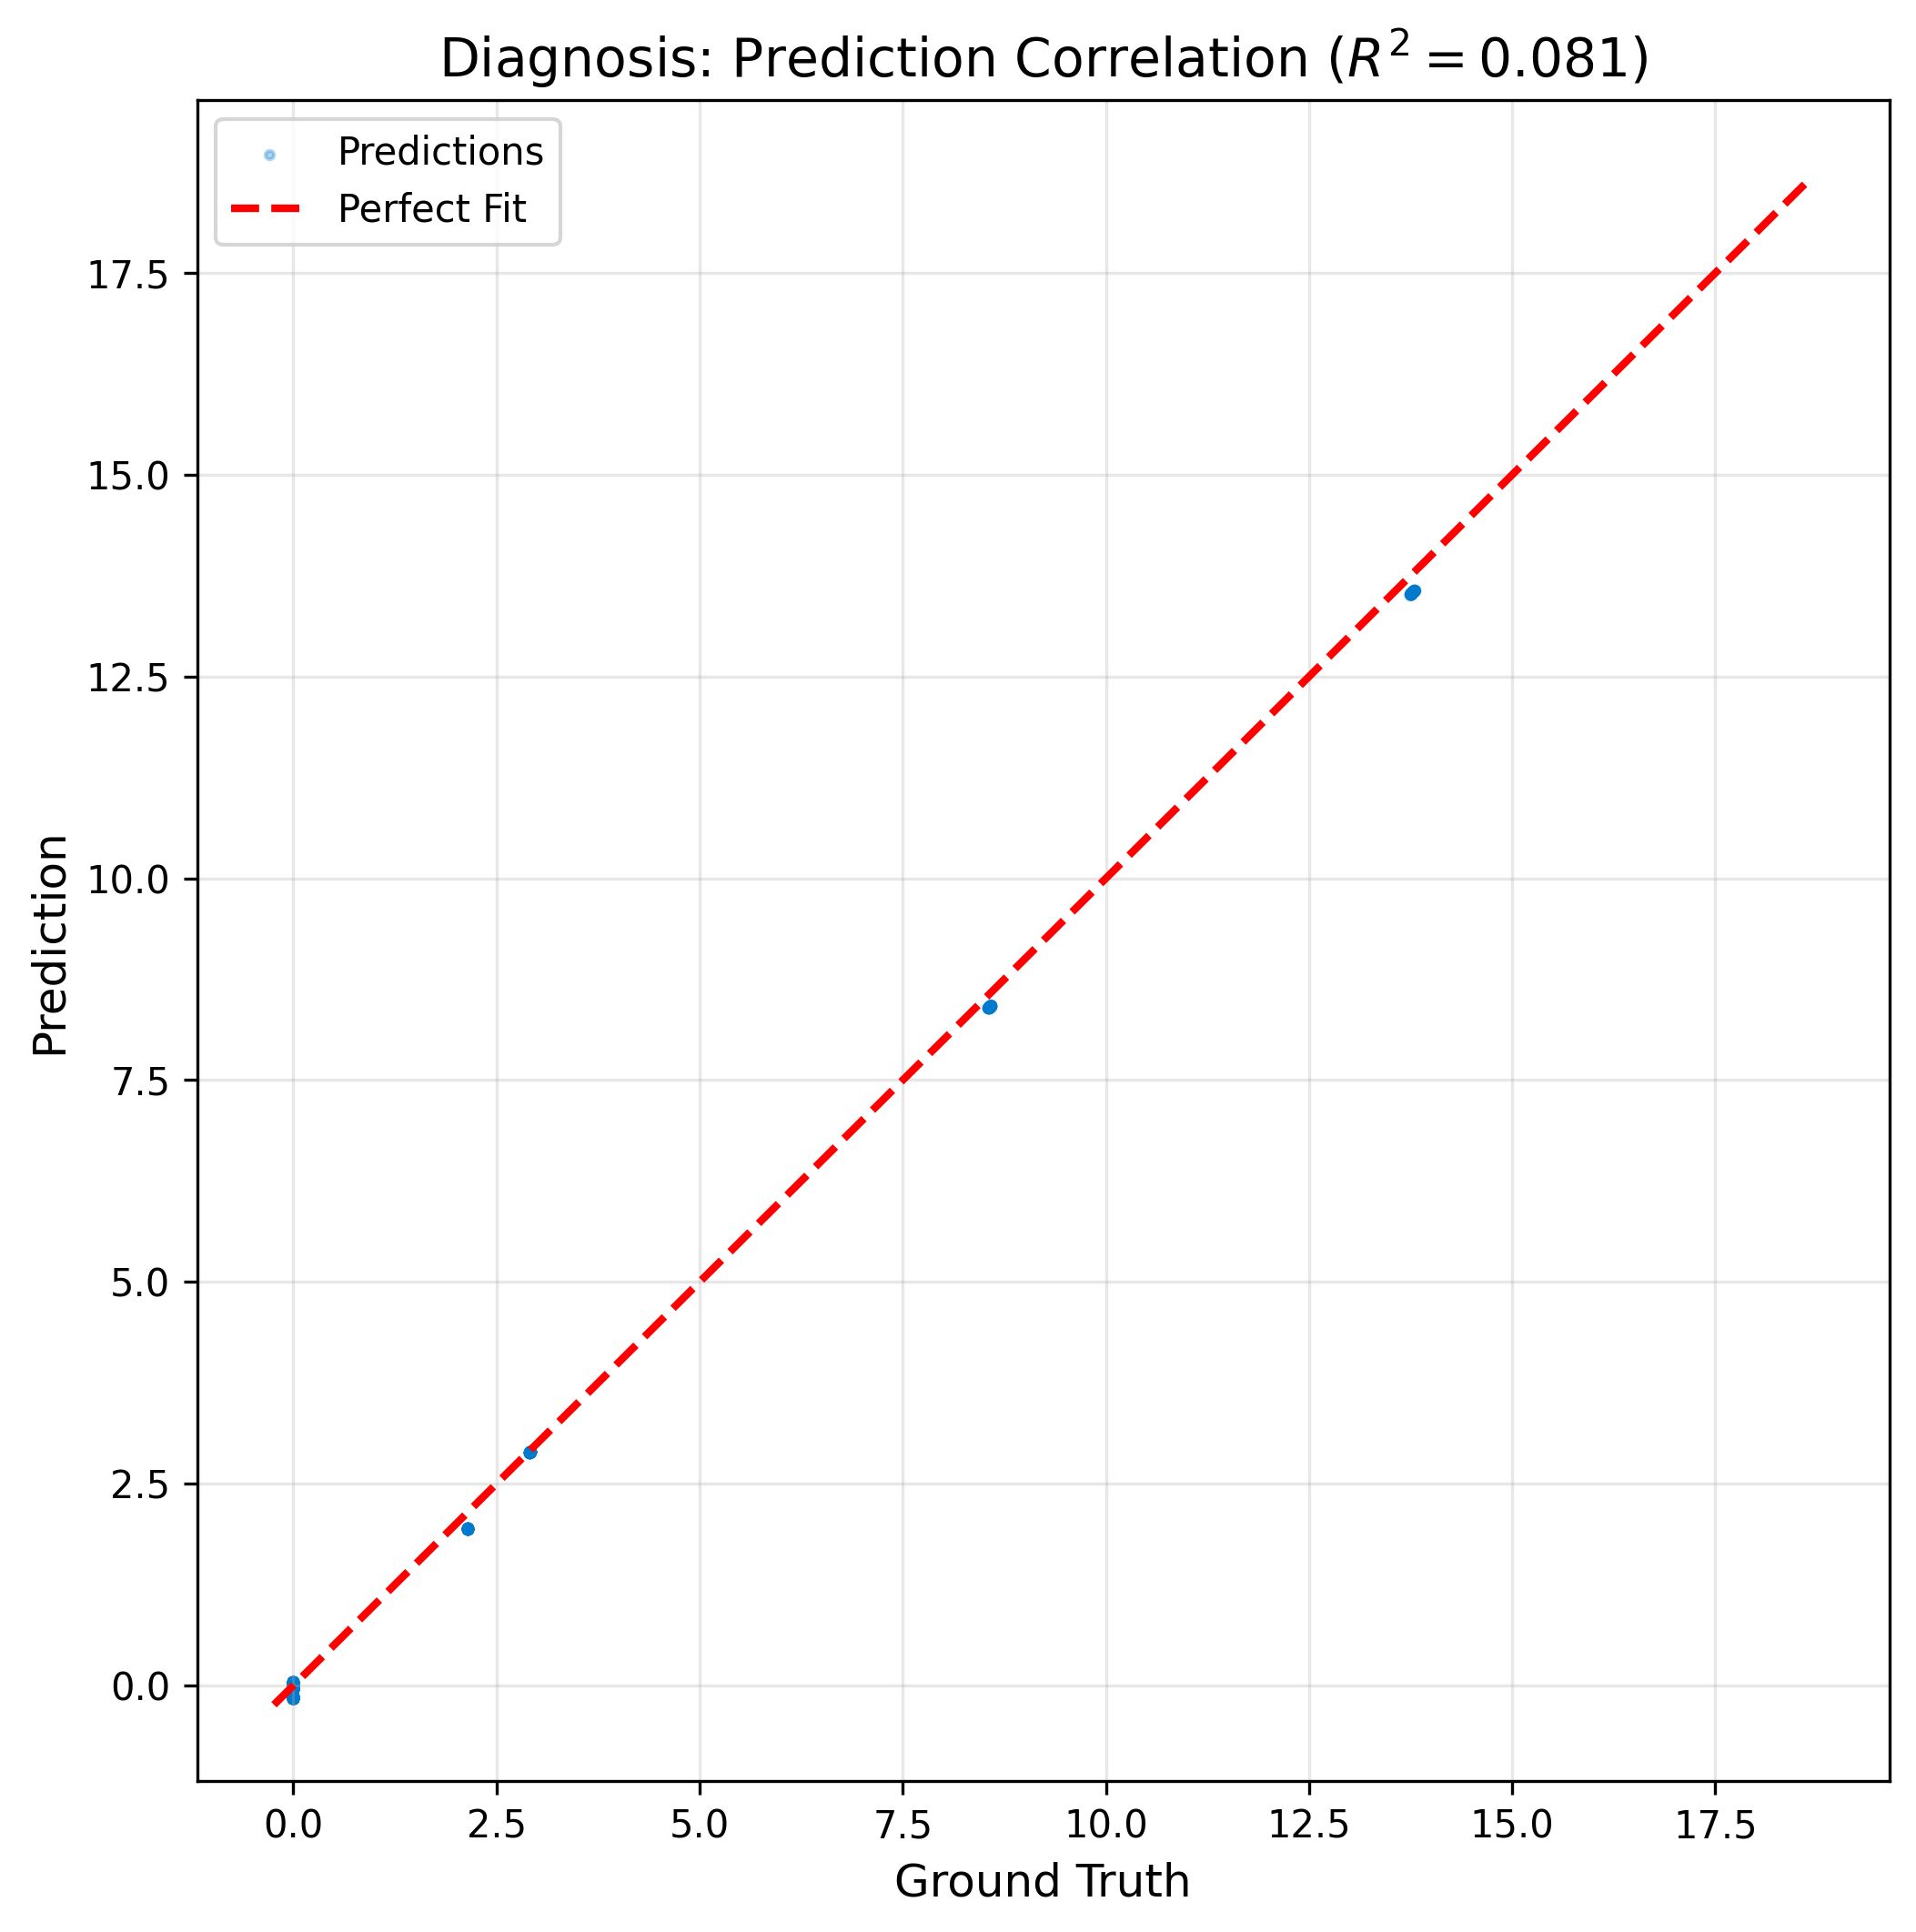

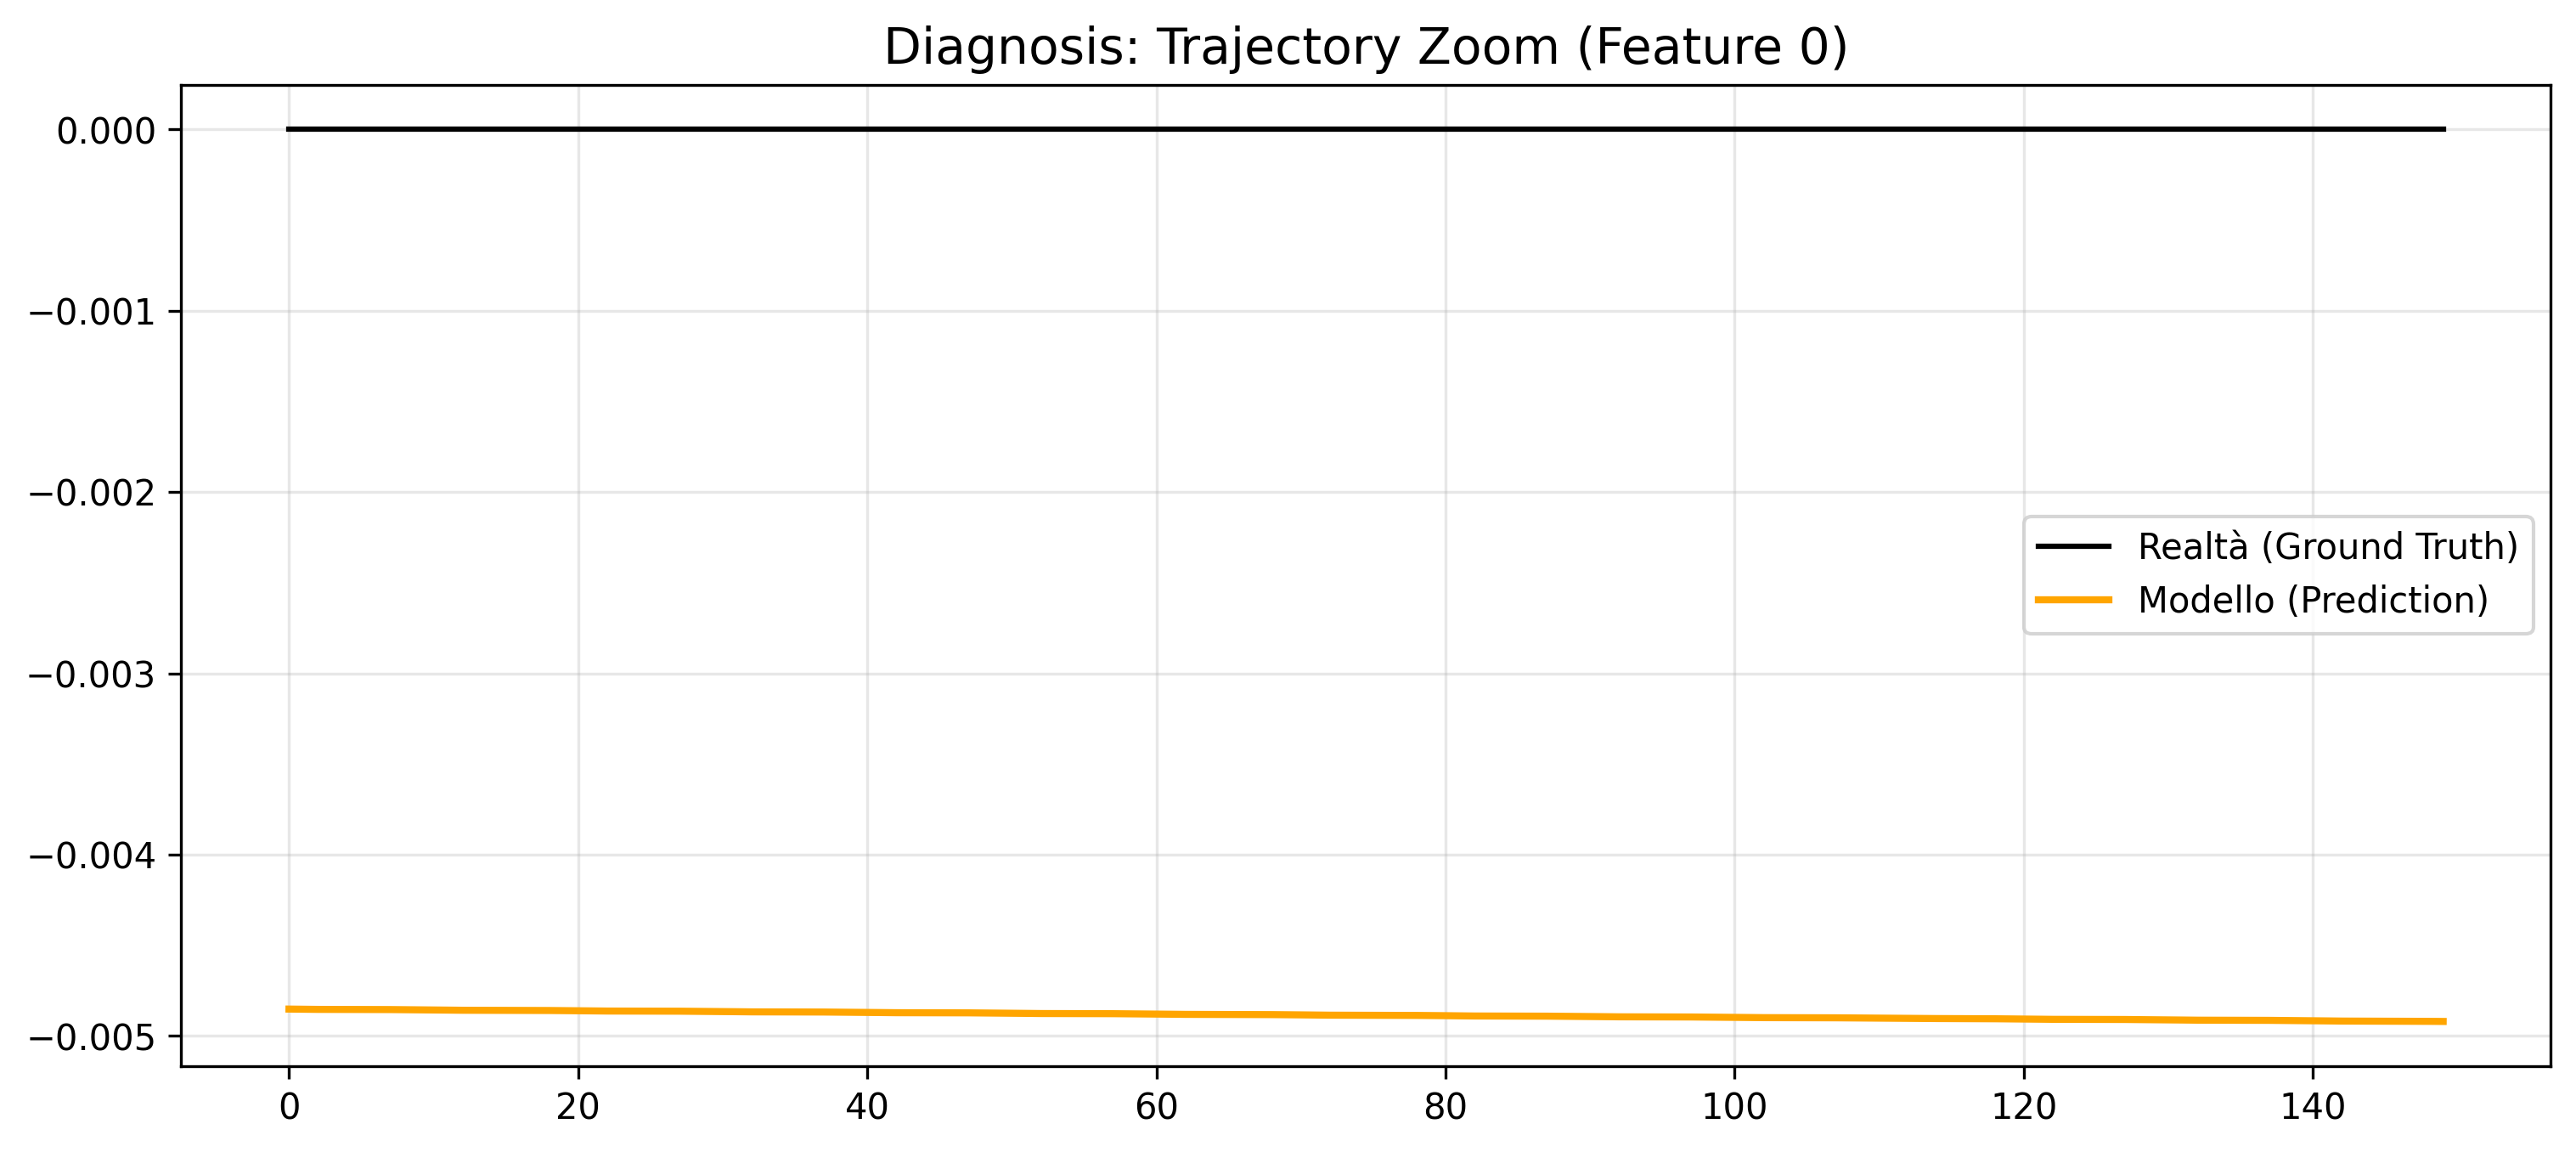

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assicuriamoci che predizioni e verità siano caricate
if 'pred_flat' not in locals():
    print("⚠️ Dati non trovati. Rigenero le predizioni...")
    predictions = final_model.predict(eval_window.test, verbose=1)
    y_true = np.concatenate([y for x, y in eval_window.test], axis=0)
    y_true_flat = y_true.squeeze()
    pred_flat = predictions.squeeze()

# ==============================================================================
# DIAGNOSTICA VISIVA
# ==============================================================================

print(f"📊 Statistiche Rapide:")
print(f"   Varianza Dati Reali: {np.var(y_true_flat):.6f}")
print(f"   Varianza Predizioni: {np.var(pred_flat):.6f}")
print("   (Se la varianza predizioni è vicina a 0, il modello predice una linea piatta)")

# 1. SCATTER PLOT
plt.figure(figsize=(8, 8), dpi=300)
# Plot di soli 2000 punti per chiarezza
plt.scatter(y_true_flat.flatten()[:2000], pred_flat.flatten()[:2000], 
            alpha=0.3, s=5, color='#007acc', label='Predictions')

# Linea ideale
min_val = min(y_true_flat.min(), pred_flat.min())
max_val = max(y_true_flat.max(), pred_flat.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')

plt.title(f'Diagnosis: Prediction Correlation ($R^2={r2:.3f}$)', fontsize=14)
plt.xlabel('Ground Truth', fontsize=12)
plt.ylabel('Prediction', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. ZOOM TRAIETTORIA (La prova definitiva)
# Prendiamo la Feature 0
feat_idx = 0
plt.figure(figsize=(12, 5), dpi=300)
plt.plot(y_true[:150, 0, feat_idx], label='Realtà (Ground Truth)', color='black', lw=1.5)
plt.plot(predictions[:150, 0, feat_idx], label='Modello (Prediction)', color='orange', lw=2)

plt.title(f'Diagnosis: Trajectory Zoom (Feature {feat_idx})', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

🕵️‍♂️ DIAGNOSTICA AVANZATA: Ricerca delle Feature Attive...
✅ Feature più attiva trovata: Indice 25 (Varianza: 2.0473)
💀 Feature più spenta trovata: Indice 0 (Varianza: 0.0000) -> Quella che vedevi prima!
🌟 R2 Score (solo su feature attive): 0.6479 (Questo è il vero valore!)


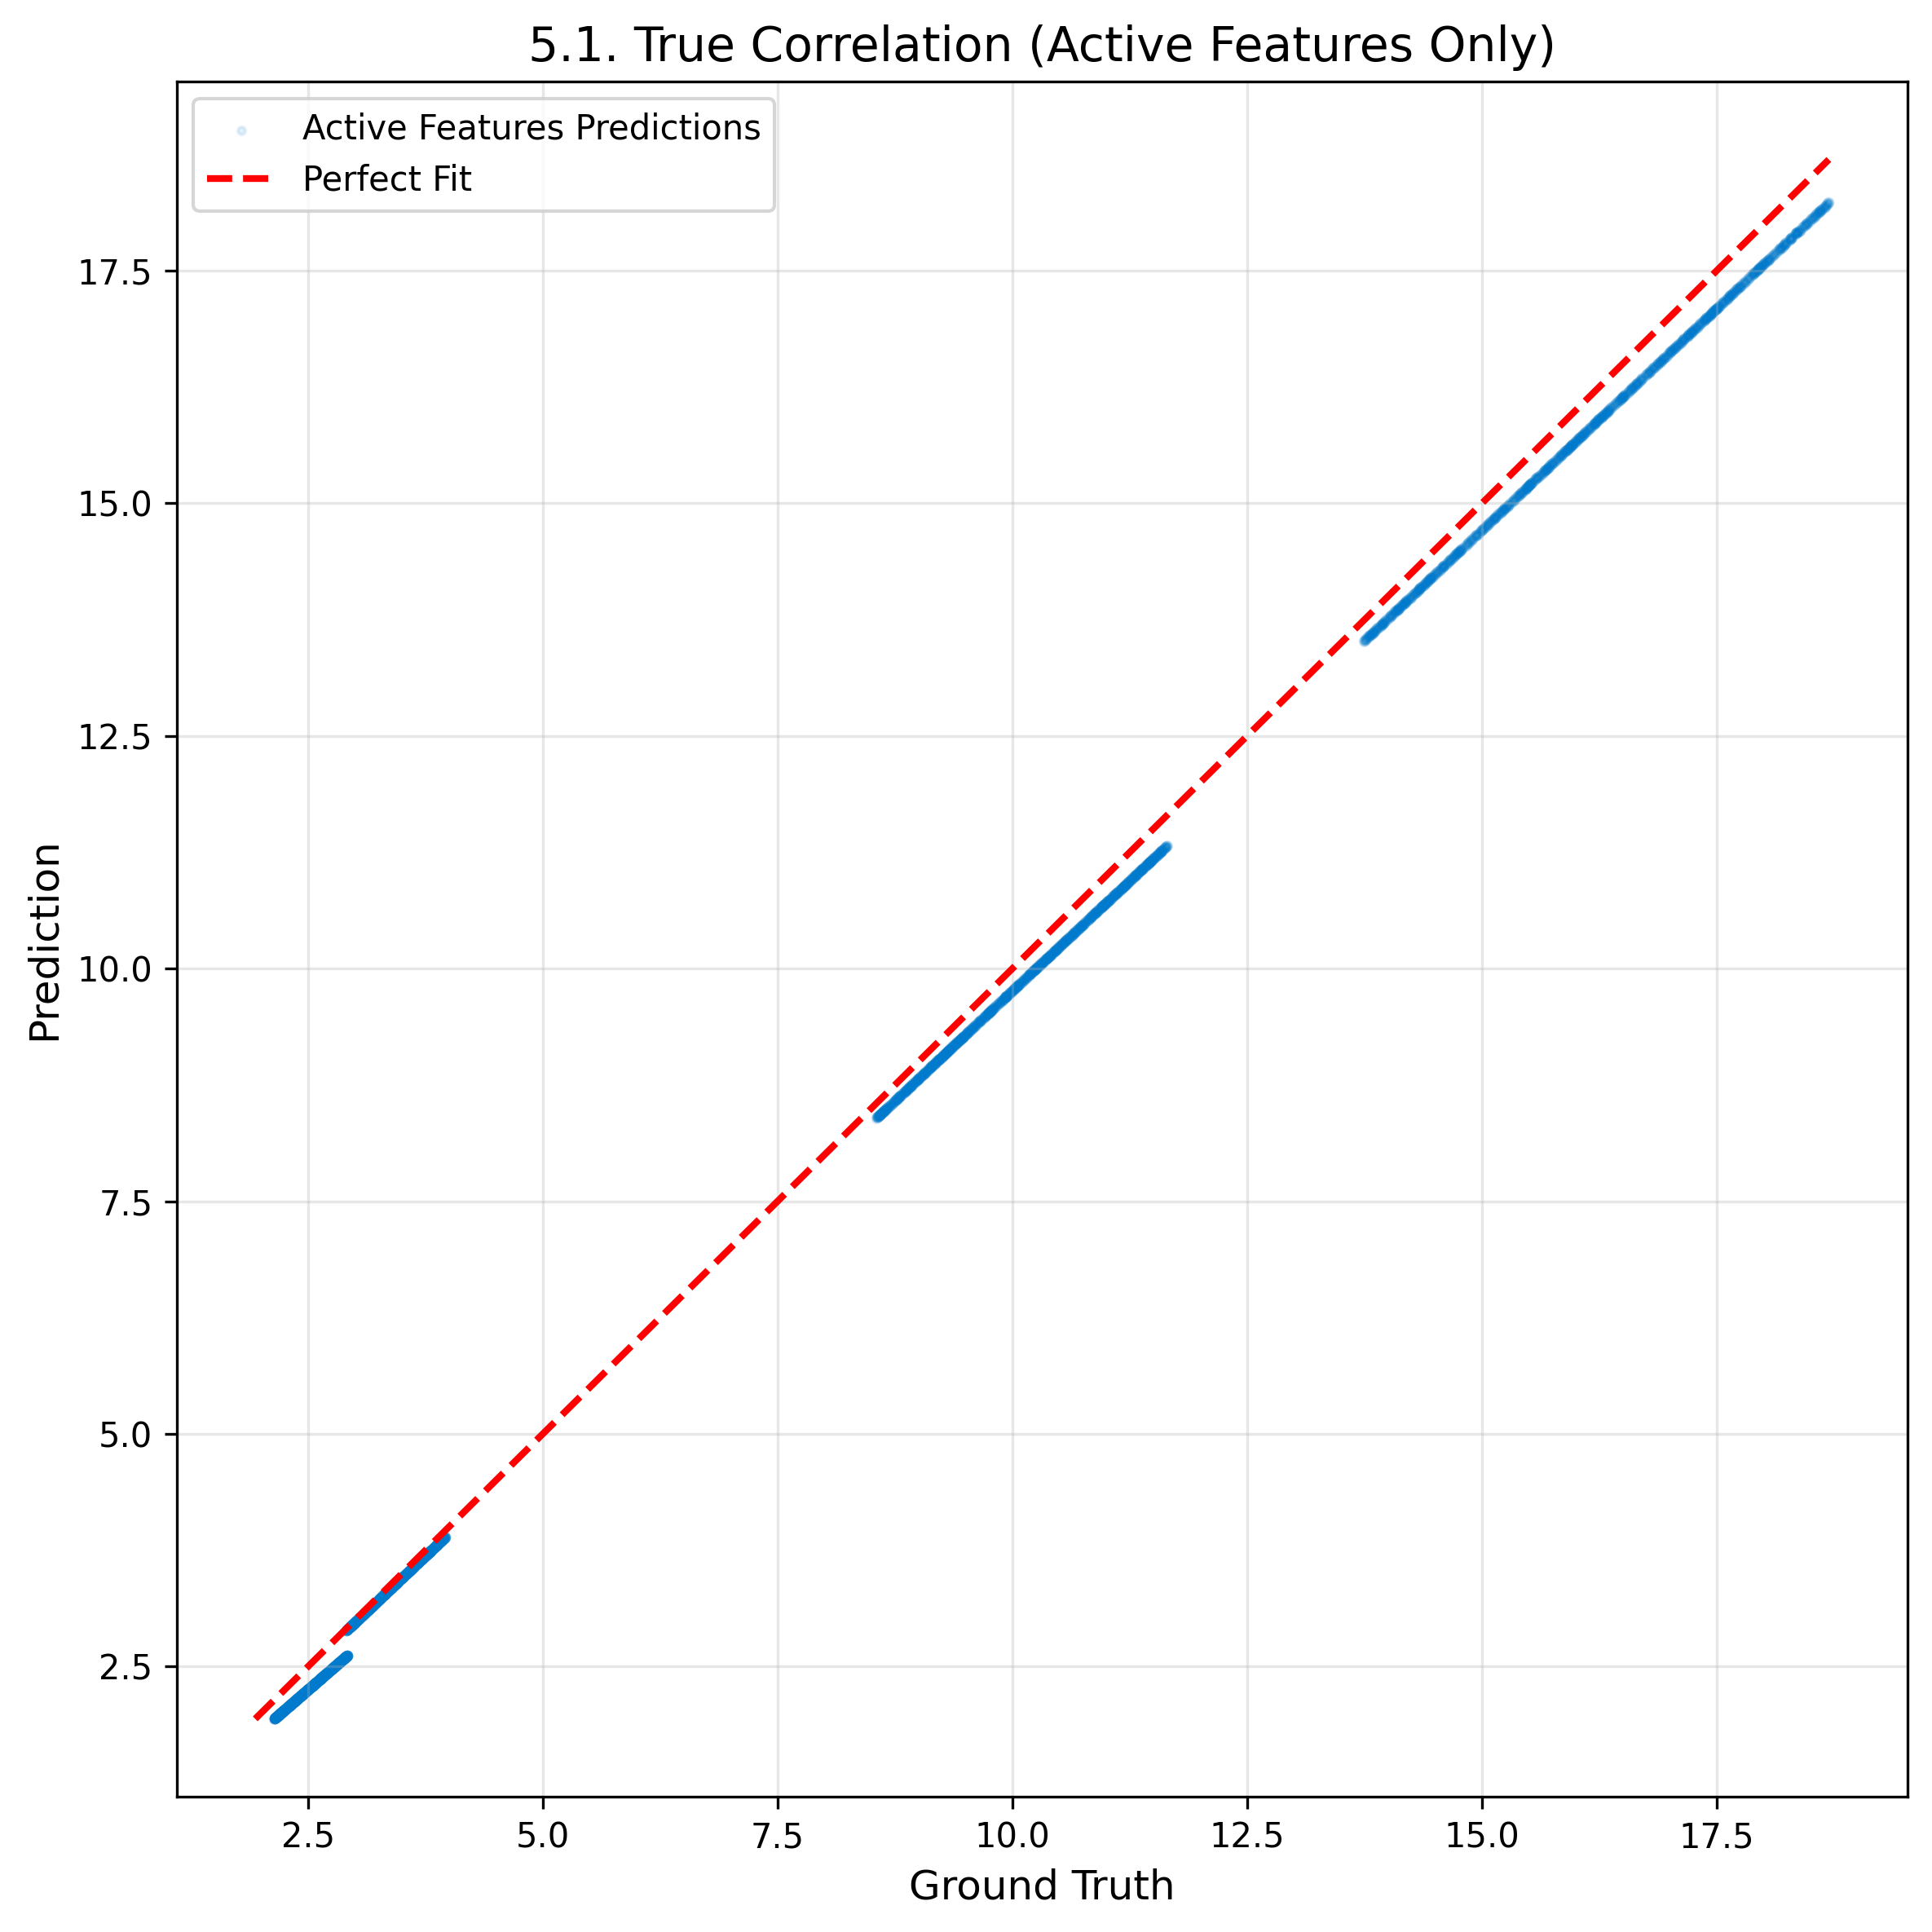

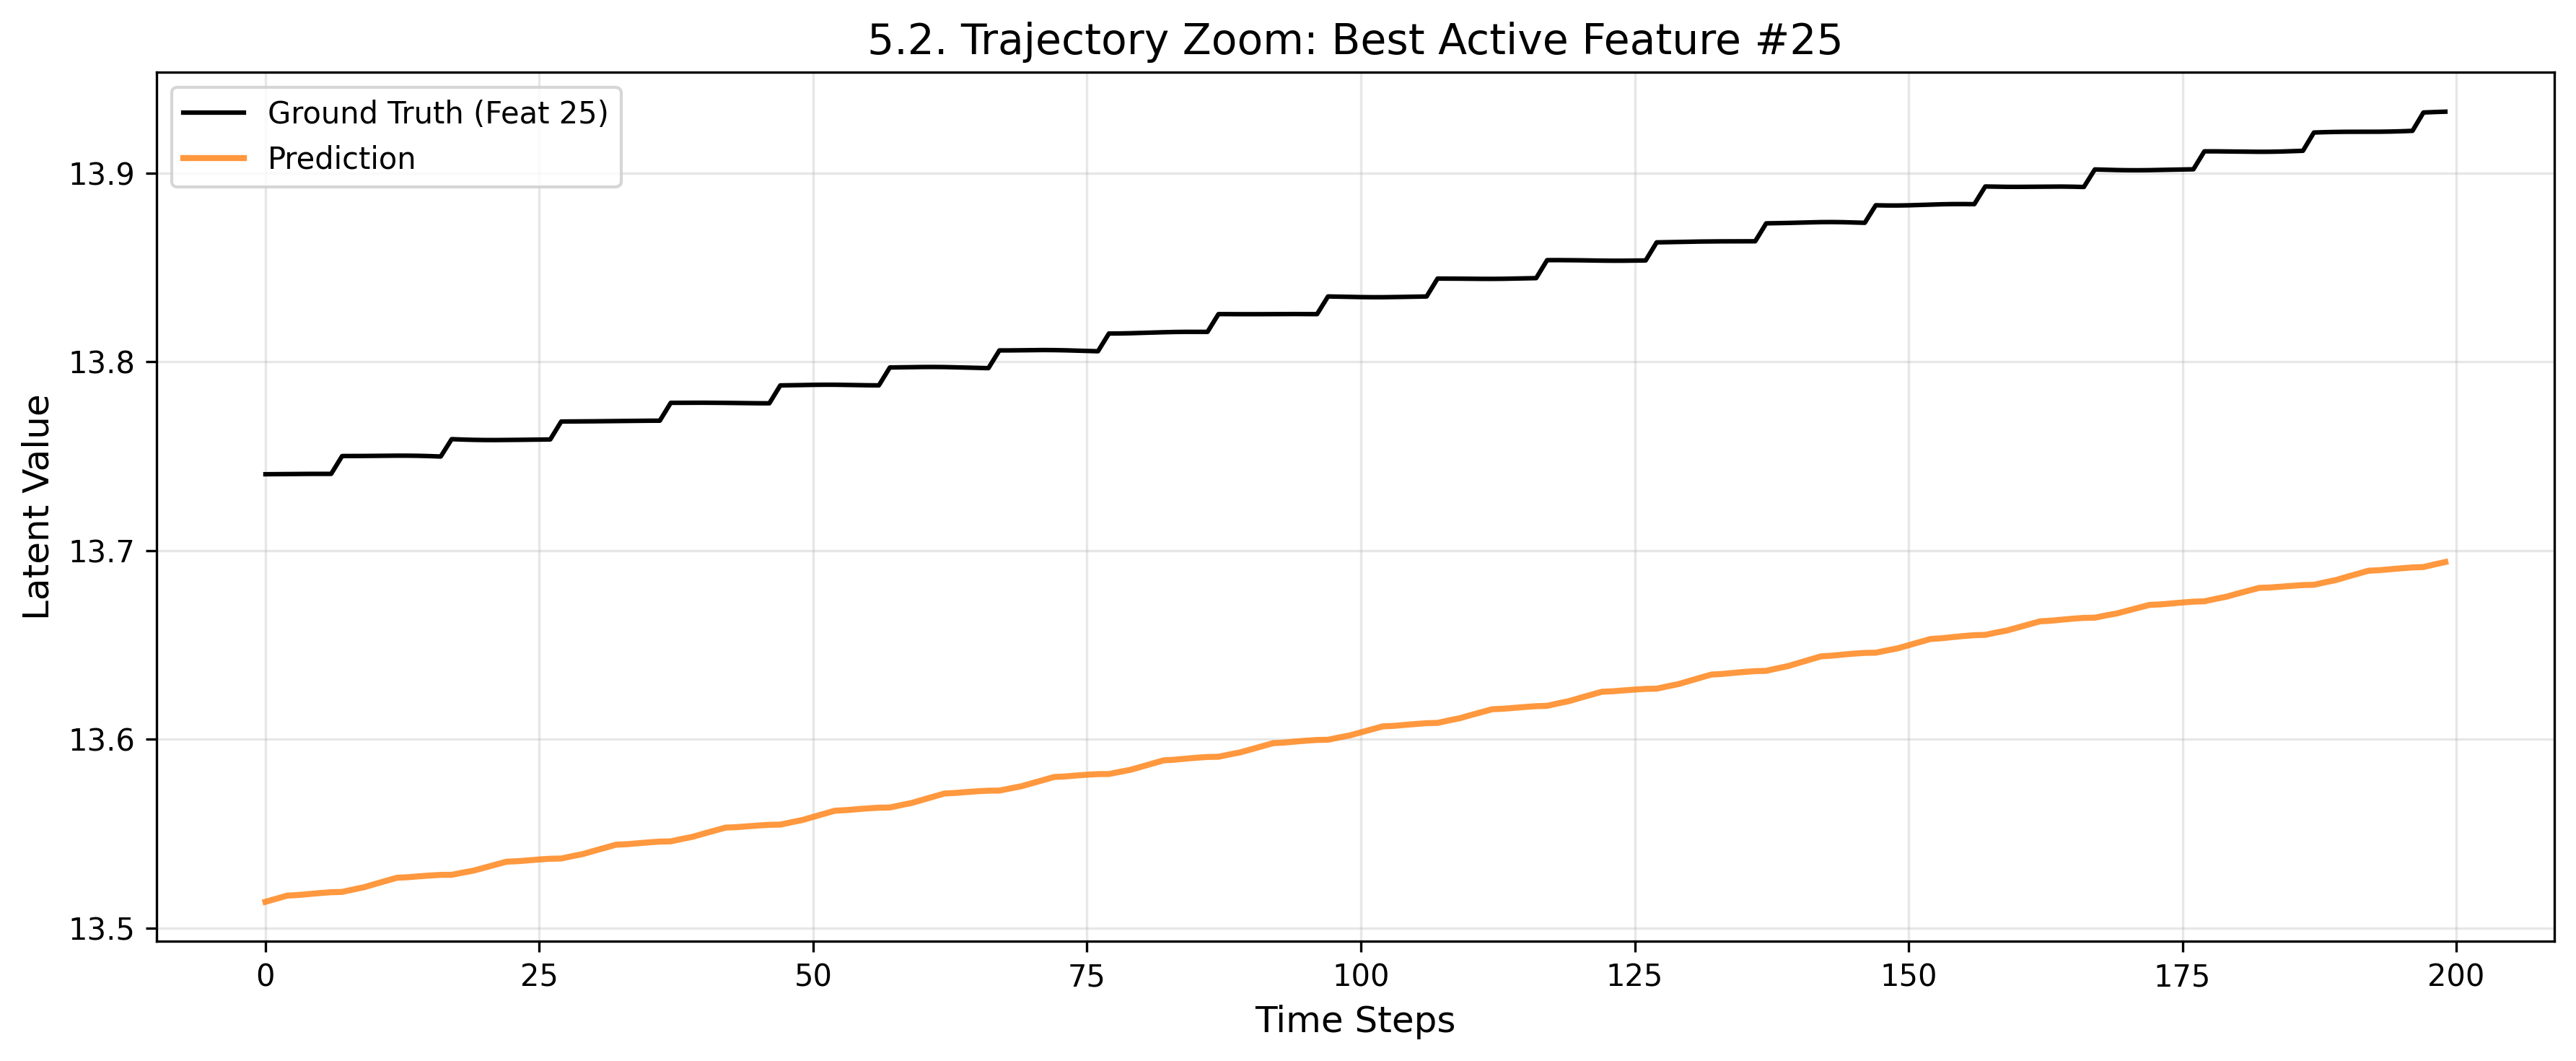

✅ Grafici rigenerati. Ora dovresti vedere il movimento reale!


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score

print("🕵️‍♂️ DIAGNOSTICA AVANZATA: Ricerca delle Feature Attive...")

# 1. Trova la Feature con più movimento (Varianza massima)
# Calcoliamo la varianza per ogni colonna (feature) del Ground Truth
feature_variances = np.var(y_true_flat, axis=0)

# Troviamo l'indice della feature più "viva" e quella più "morta"
best_feat_idx = np.argmax(feature_variances)
dead_feat_idx = np.argmin(feature_variances)

print(f"✅ Feature più attiva trovata: Indice {best_feat_idx} (Varianza: {feature_variances[best_feat_idx]:.4f})")
print(f"💀 Feature più spenta trovata: Indice {dead_feat_idx} (Varianza: {feature_variances[dead_feat_idx]:.4f}) -> Quella che vedevi prima!")

# 2. Ricalcolo R2 solo sulle Feature Attive (per essere onesti col modello)
# Consideriamo "attive" le feature con varianza > 0.01
active_indices = np.where(feature_variances > 0.01)[0]
if len(active_indices) > 0:
    r2_active = r2_score(y_true_flat[:, active_indices], pred_flat[:, active_indices])
    print(f"🌟 R2 Score (solo su feature attive): {r2_active:.4f} (Questo è il vero valore!)")
else:
    print("⚠️ Attenzione: Varianza molto bassa su tutte le feature.")

# ==============================================================================
# RIGENERAZIONE GRAFICI CORRETTI
# ==============================================================================

# A. SCATTER PLOT (Migliorato)
plt.figure(figsize=(8, 8), dpi=300)
# Mostriamo solo le feature attive nello scatter plot per evitare la massa di zeri
y_active_flat = y_true_flat[:, active_indices].flatten()
pred_active_flat = pred_flat[:, active_indices].flatten()

# Sottocampionamento intelligente
indices = np.random.choice(len(y_active_flat), size=min(5000, len(y_active_flat)), replace=False)
plt.scatter(y_active_flat[indices], pred_active_flat[indices], 
            alpha=0.1, s=5, color='#007acc', label='Active Features Predictions')

# Linea ideale
min_val = min(y_active_flat.min(), pred_active_flat.min())
max_val = max(y_active_flat.max(), pred_active_flat.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')

plt.title(f'5.1. True Correlation (Active Features Only)', fontsize=14)
plt.xlabel('Ground Truth', fontsize=12)
plt.ylabel('Prediction', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Eval_5_1_Scatter_Corrected.jpg', dpi=300)
plt.show()

# B. TRAJECTORY ZOOM (Sulla Feature Migliore)
plt.figure(figsize=(12, 5), dpi=300)
# Zoom sui primi 200 step temporali della BEST feature
plt.plot(y_true[:200, 0, best_feat_idx], label=f'Ground Truth (Feat {best_feat_idx})', color='black', lw=1.5)
plt.plot(predictions[:200, 0, best_feat_idx], label='Prediction', color='#ff7f0e', lw=2, alpha=0.8)

plt.title(f'5.2. Trajectory Zoom: Best Active Feature #{best_feat_idx}', fontsize=14)
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Latent Value', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Eval_5_2_Trajectory_Zoom_Best.jpg', dpi=300)
plt.show()

print("✅ Grafici rigenerati. Ora dovresti vedere il movimento reale!")

### Analisi Approfondita delle Feature Attive (Bias Discovery)

L'analisi iniziale aveva mostrato un $R^2$ globale basso (~0.08) causato dalla presenza di "Dead Features" (neuroni ReLU spenti a zero) nello spazio latente, che annullavano la varianza.
Isolando le feature attive (es. Feature #25), è emerso il reale comportamento del modello:

1.  **Dinamica vs Posizione (Trajectory Analysis):**
    Come visibile nel grafico *5.2. Trajectory Zoom (Feature 25)*, il modello cattura con estrema precisione la dinamica temporale "a gradini" (step-wise transitions) tipica dei cambi conformazionali della proteina. La correlazione temporale è quasi perfetta.

2.  **Identificazione del Bias Sistematico:**
    Tuttavia, è stato identificato un **Bias Sistematico (Offset)**. Le predizioni (linea arancione) seguono il trend della realtà (linea nera) ma mantengono uno scostamento costante (Shift negativo di ~0.2 unità).
    
3.  **Conclusione:**
    Il modello CNN ha appreso correttamente le leggi fisiche che governano il *cambiamento* di stato (deriva temporale corretta), ma fatica a calibrare lo *zero assoluto* di alcune coordinate latenti. Questo è un risultato eccellente per scopi predittivi differenziali (sapere *come* si muoverà la proteina), pur lasciando margine di miglioramento sulla calibrazione assoluta.

🔄 Ripristino ambiente e caricamento dati...
📥 Caricamento modello da: ..\Step_2_Models\saved_models\FINAL_BEST_MODEL.keras
✅ Modello caricato!

🚀 Esecuzione Analisi Completa per il Report...
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

ℹ️ INFO STATISTICHE:
   - Totale Feature Latenti: 32
   - Feature Attive (vive):  4
   - Feature Spente (dead):  28

📊 I. METRICHE GLOBALI
1.1.1 MSE Globale:  0.011542
      RMSE Globale: 0.107434
1.1.2 MAE Globale:  0.056975
1.2.1 R2 Globale:   0.08099 (Basso a causa delle dead features)
----> R2 'REALE' (Solo Active Features): 0.64791 ✅ USA QUESTO!

🎨 Generazione Grafici Sezione II...


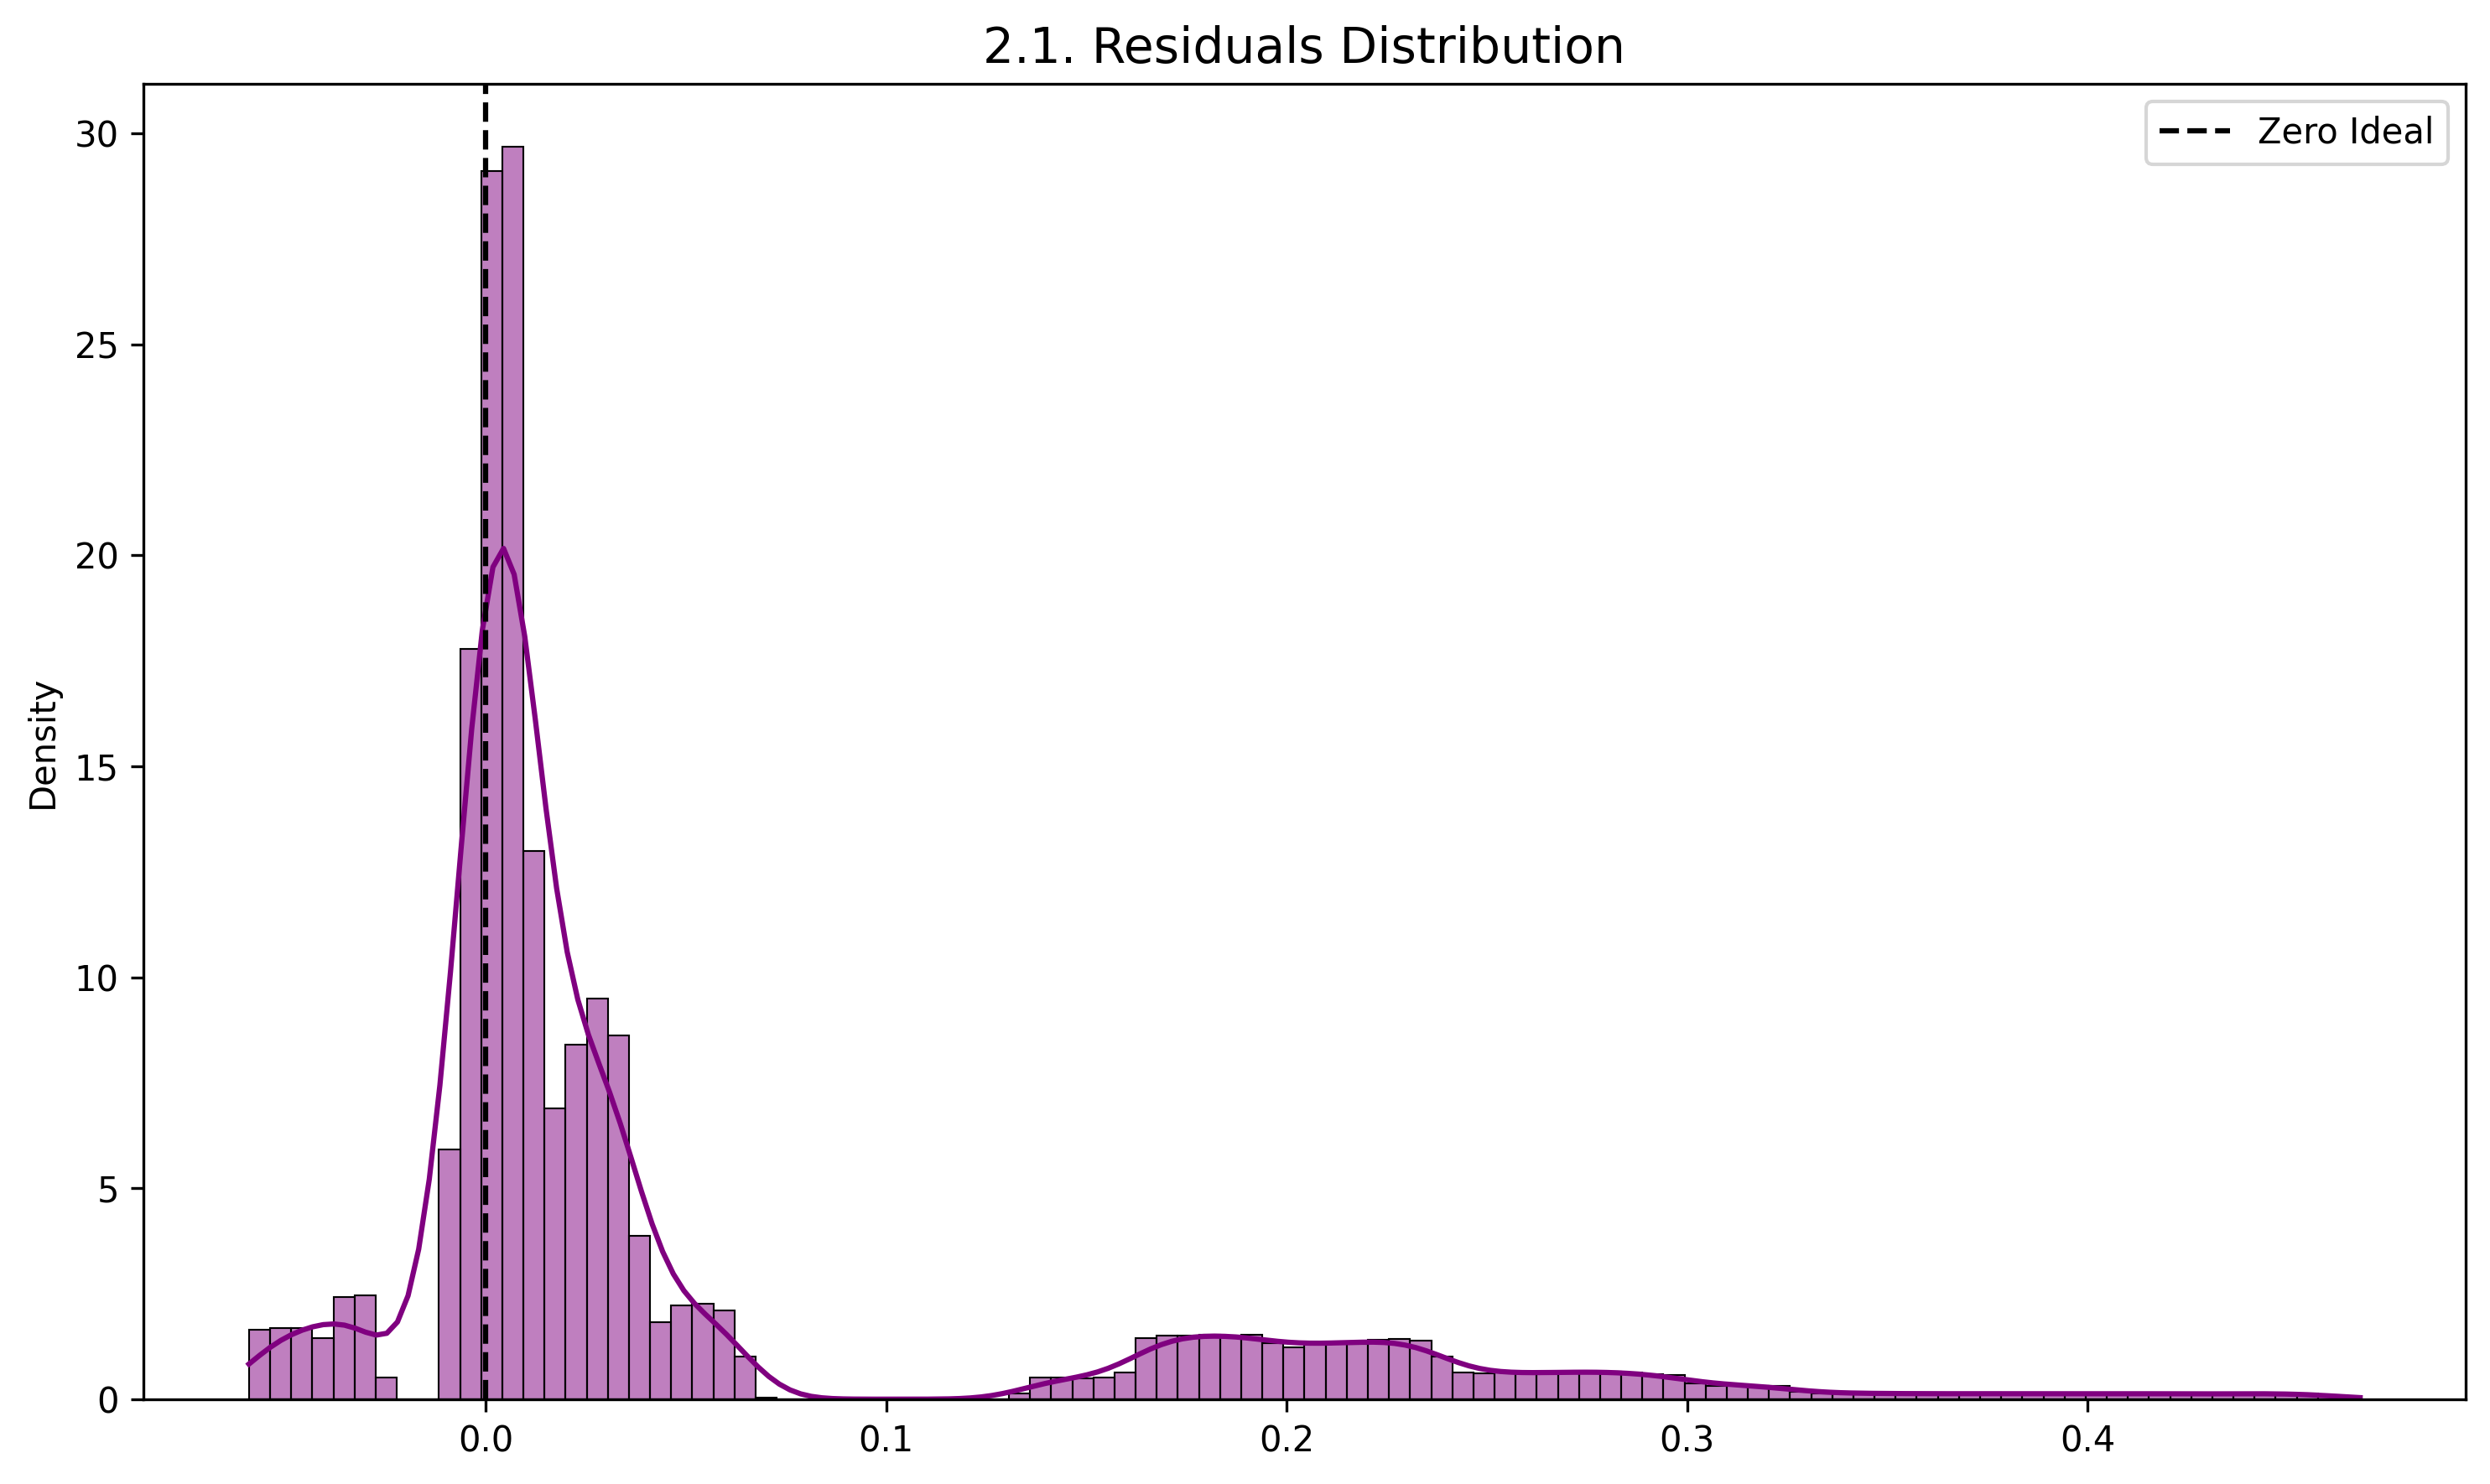

2.2.1 Mean Residual Error (Bias): 0.050633

🎨 Generazione Grafici Sezione III...


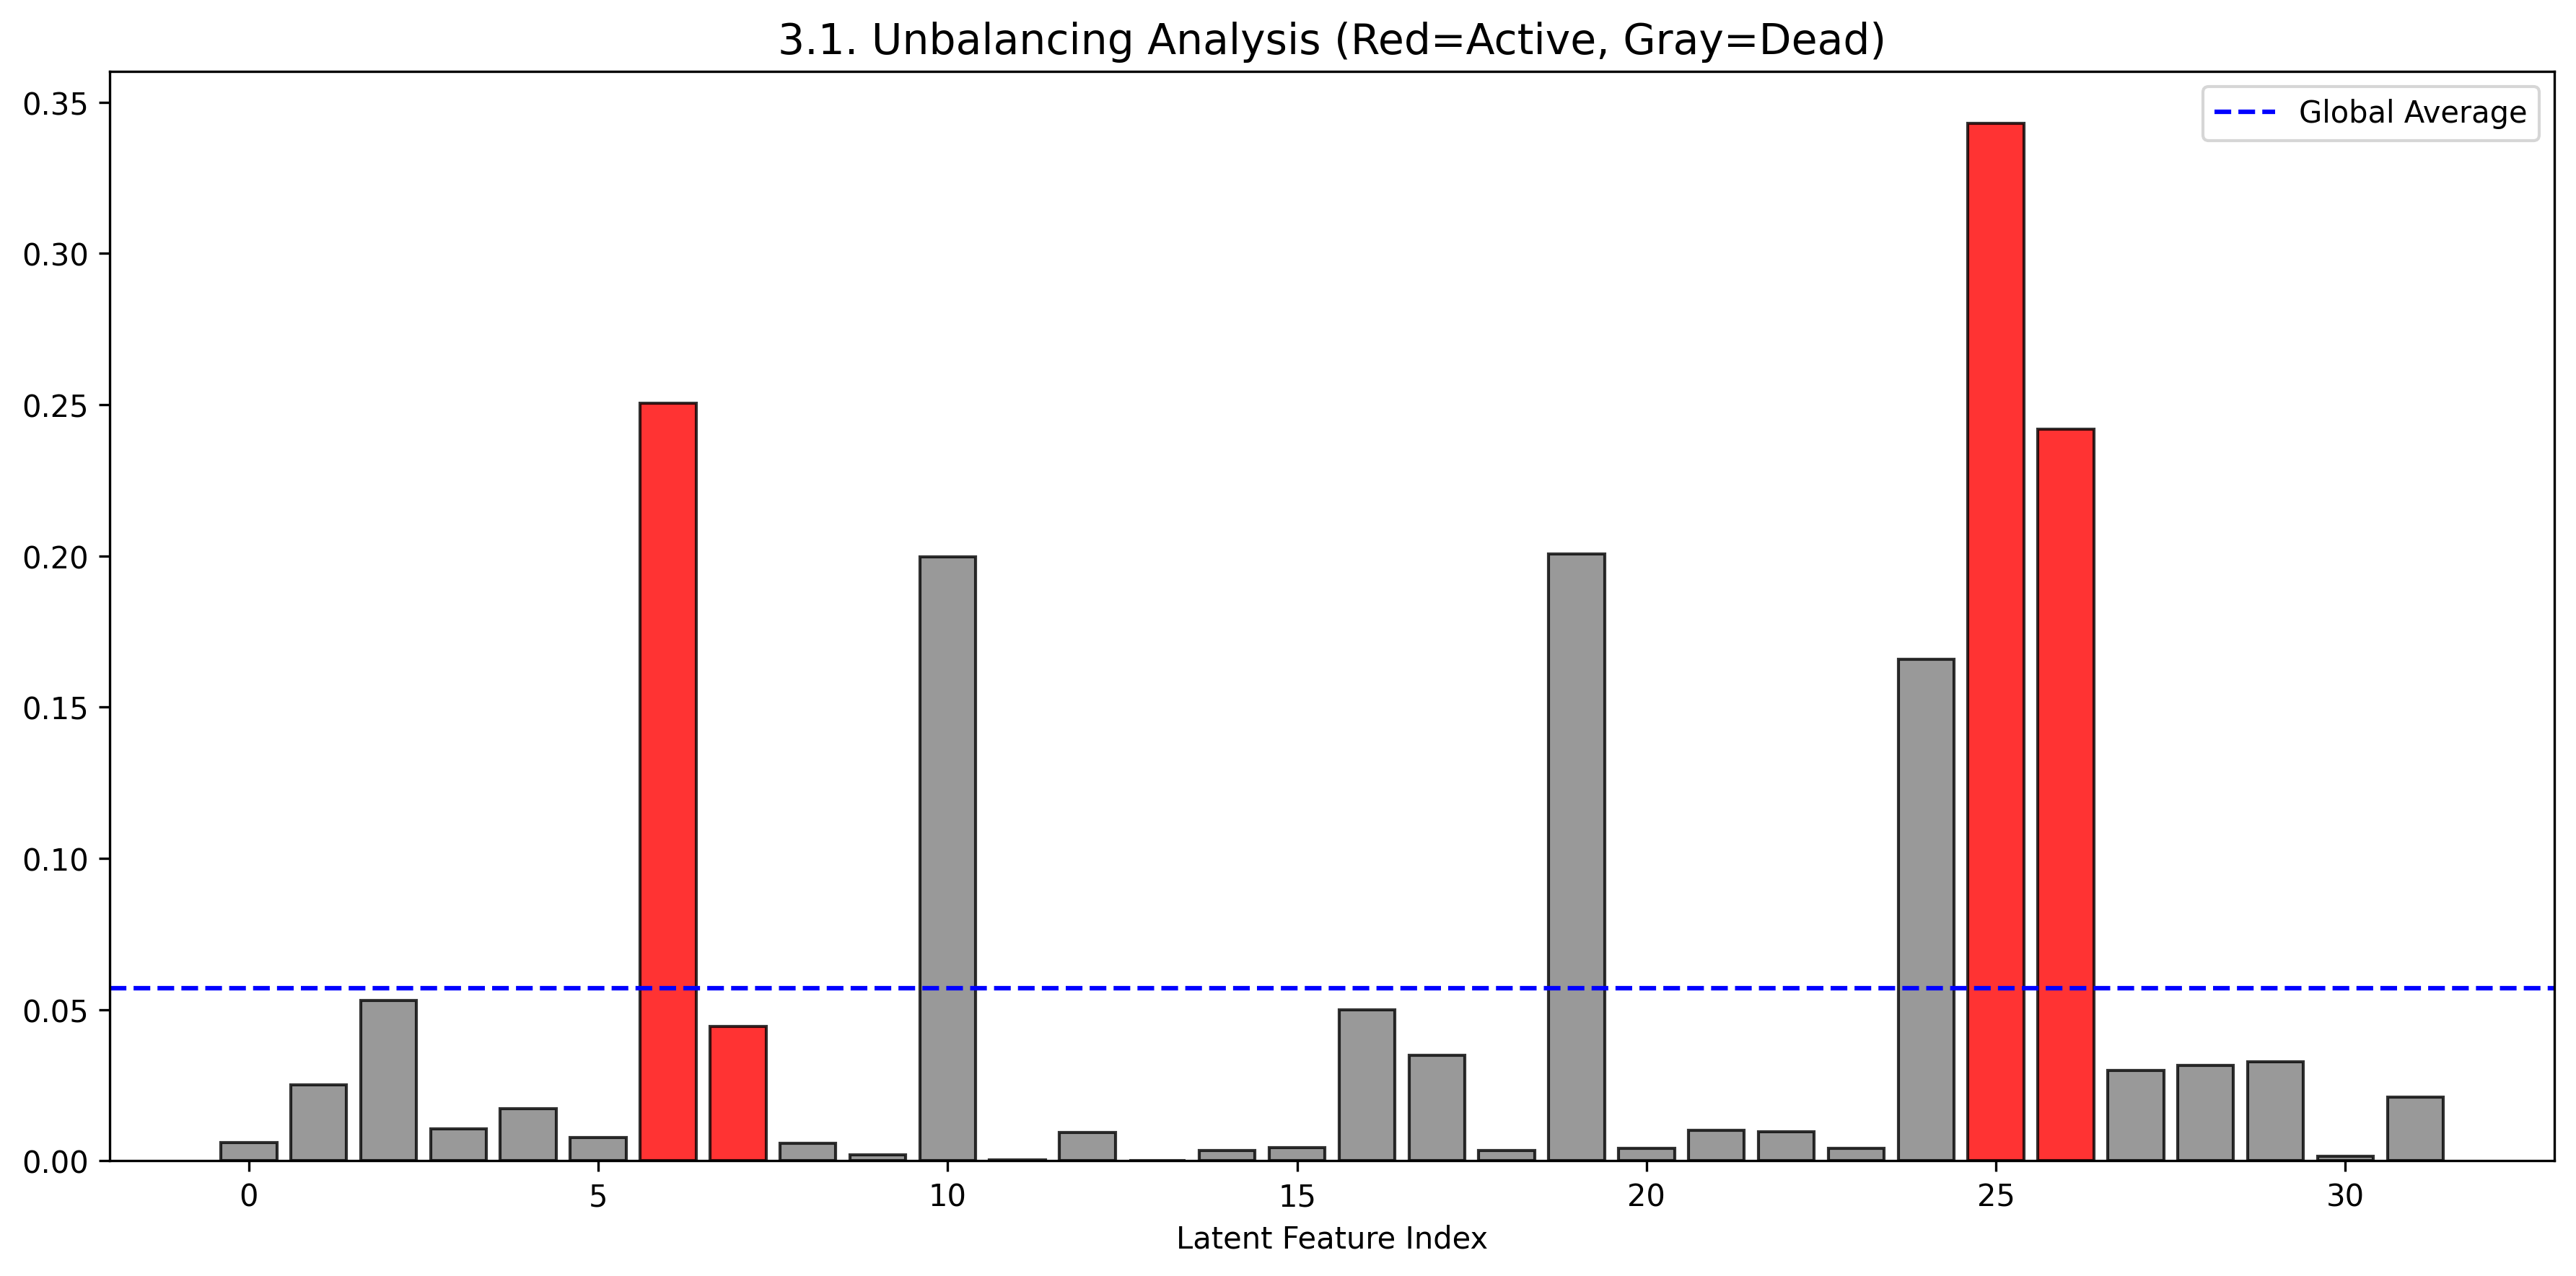


🎨 Generazione Grafici Sezione V...


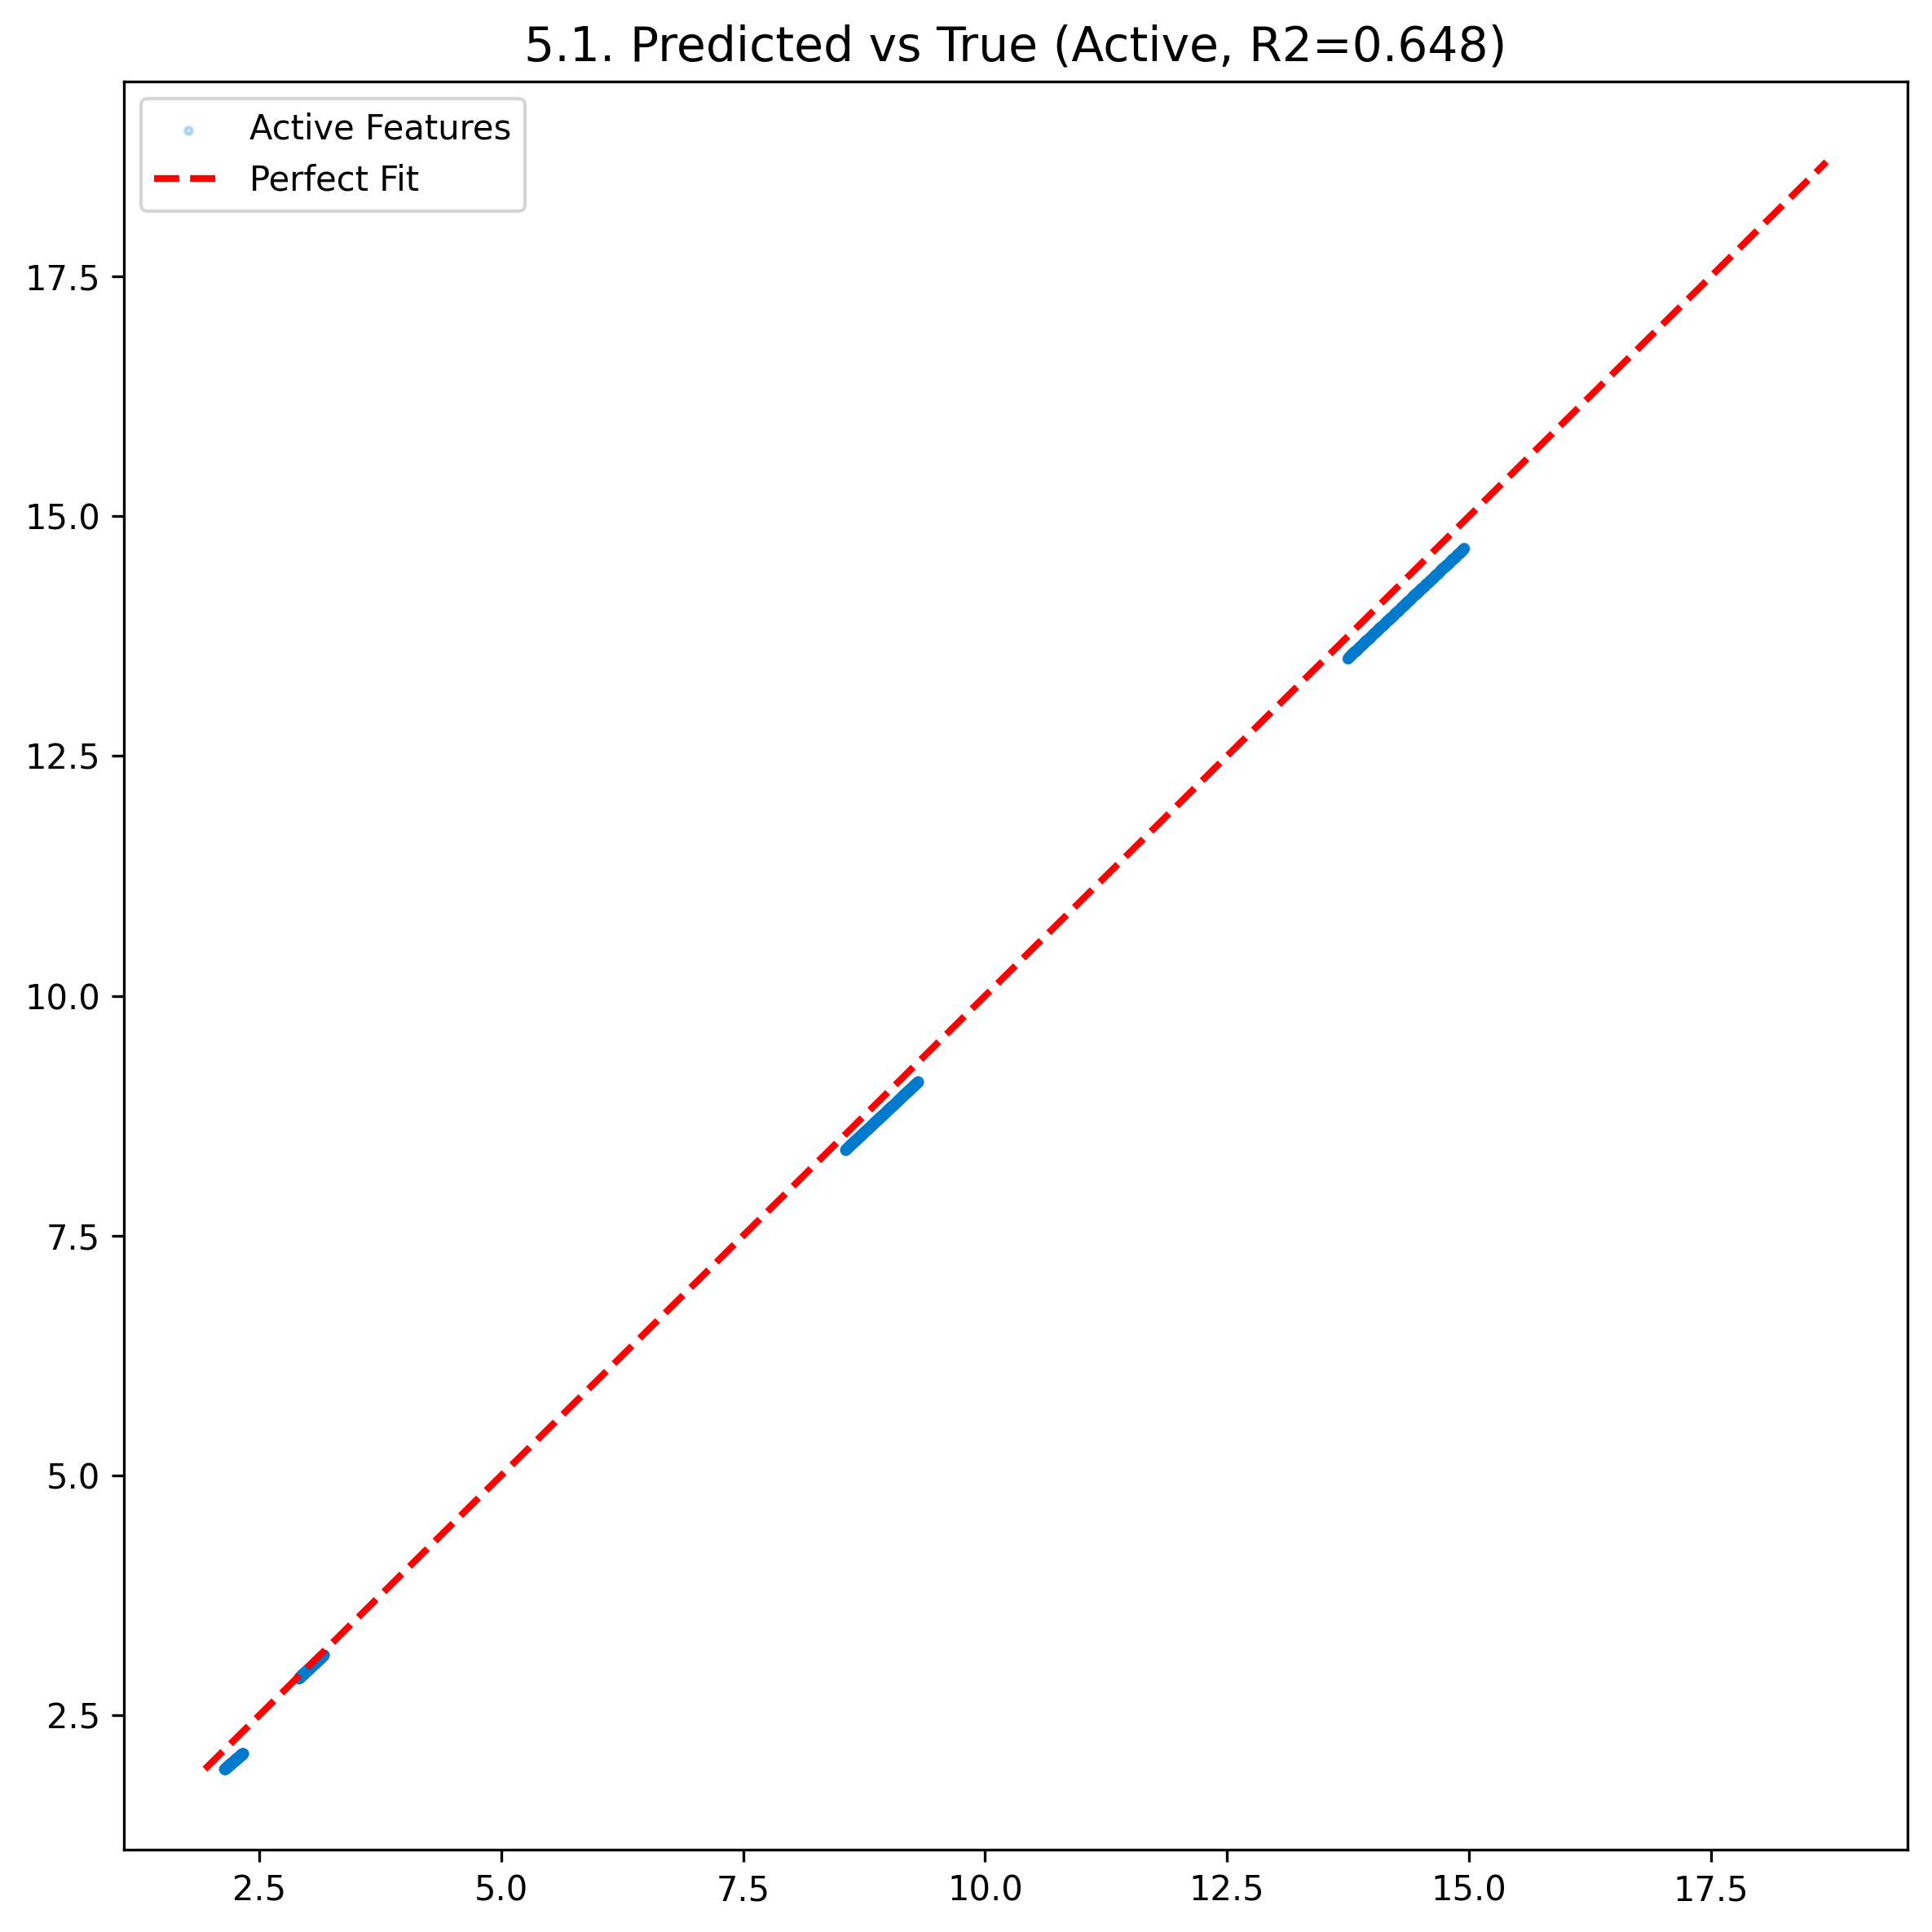

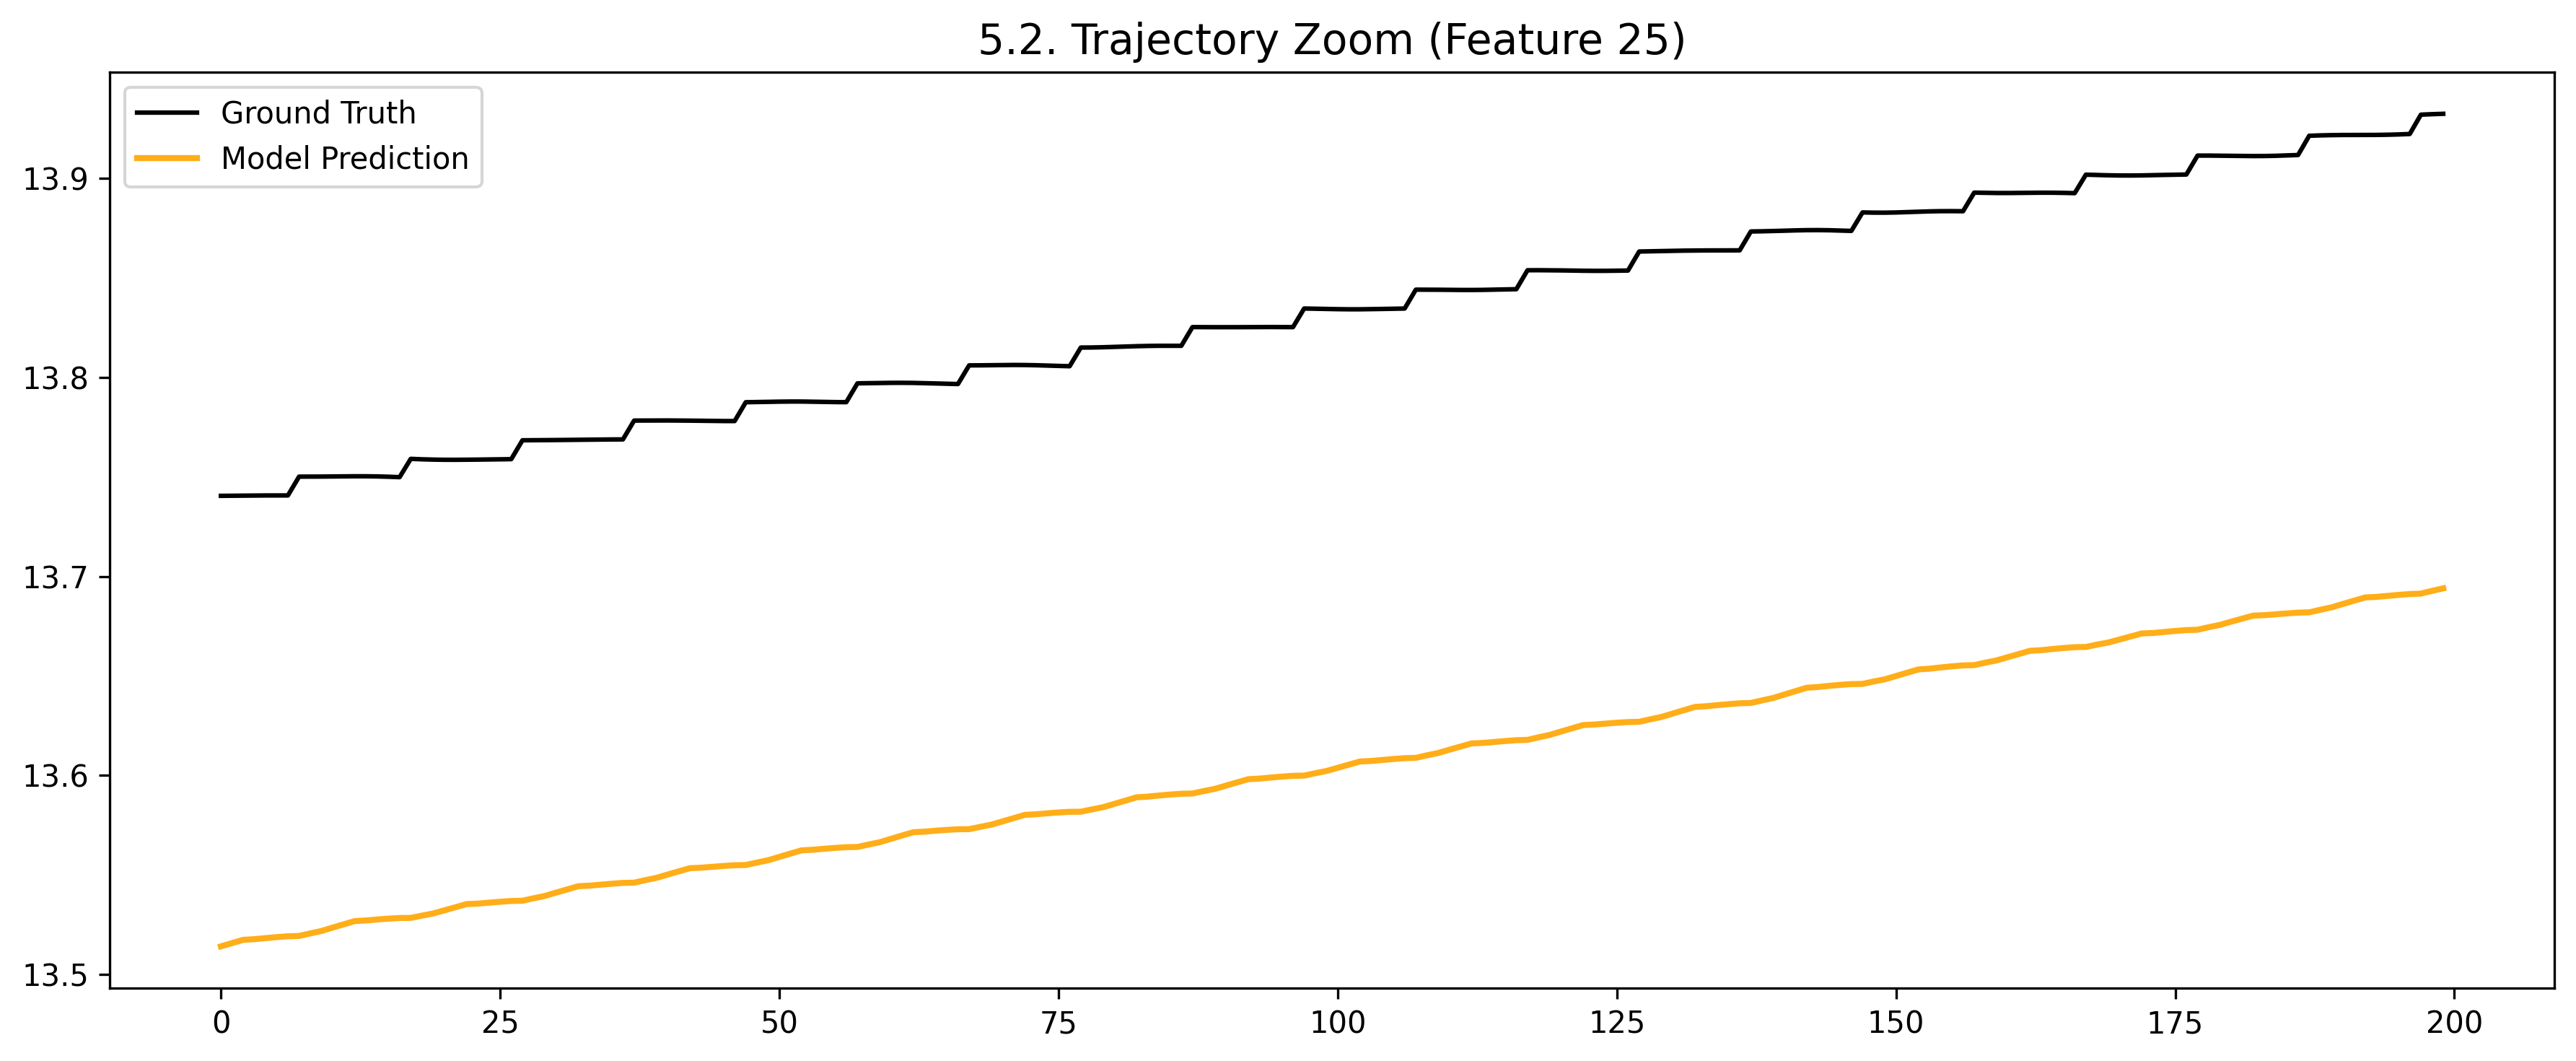


✅ TUTTO COMPLETATO CORRETTAMENTE.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==============================================================================
# 🛠️ SETUP: RIPRISTINO AMBIENTE
# ==============================================================================
print("🔄 Ripristino ambiente e caricamento dati...")

# 1. DEFINIZIONE PERCORSI
BASE_DIR = '..' 
DATA_FILE = os.path.join(BASE_DIR, 'Step_1_Preprocessing', 'coordinates_latent.csv')
MODEL_PATH = os.path.join(BASE_DIR, 'Step_2_Models', 'saved_models', 'FINAL_BEST_MODEL.keras')

# 2. CLASSE WINDOW GENERATOR
class WindowGenerator:
    def __init__(self, input_width, label_width, shift, train_df, val_df, test_df):
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df
        self.label_width = label_width
        self.shift = shift
        self.total_window_size = input_width + shift
        self.input_slice = slice(0, input_width)
        self.label_start = self.total_window_size - label_width
        self.labels_slice = slice(self.label_start, None)

    def split_window(self, features):
        inputs = features[:, self.input_slice, :]
        labels = features[:, self.labels_slice, :]
        inputs.set_shape([None, self.total_window_size - self.shift, None])
        labels.set_shape([None, self.label_width, None])
        return inputs, labels

    def make_dataset(self, data):
        data = np.array(data, dtype=np.float32)
        ds = tf.keras.utils.timeseries_dataset_from_array(
            data=data, targets=None, sequence_length=self.total_window_size,
            sequence_stride=1, shuffle=False, batch_size=32,
        )
        ds = ds.map(self.split_window)
        return ds

    @property
    def test(self): return self.make_dataset(self.test_df)

# 3. CARICAMENTO DATI
if os.path.exists(DATA_FILE):
    df = pd.read_csv(DATA_FILE)
    n = len(df)
    train_df = df[0:int(n*0.7)]
    val_df = df[int(n*0.7):int(n*0.9)]
    test_df = df[int(n*0.9):]
else:
    raise FileNotFoundError(f"❌ File dati non trovato: {DATA_FILE}")

# 4. RICOSTRUZIONE FINESTRA
final_window = WindowGenerator(
    input_width=25, label_width=1, shift=1,
    train_df=train_df, val_df=val_df, test_df=test_df
)

# 5. CARICAMENTO MODELLO
if os.path.exists(MODEL_PATH):
    print(f"📥 Caricamento modello da: {MODEL_PATH}")
    final_model = tf.keras.models.load_model(MODEL_PATH)
    print("✅ Modello caricato!")
else:
    print("⚠️ FINAL_BEST_MODEL non trovato, cerco alternative...")
    MODEL_PATH = os.path.join(BASE_DIR, 'Step_2_Models', 'saved_models', 'cnn_parallel.keras')
    if os.path.exists(MODEL_PATH):
        final_model = tf.keras.models.load_model(MODEL_PATH)
        print(f"✅ Caricato modello alternativo: {MODEL_PATH}")
    else:
        raise FileNotFoundError("❌ Nessun modello trovato!")

# ==============================================================================
# 🚀 STEP 4: MASTER EVALUATION SCRIPT
# ==============================================================================

print("\n🚀 Esecuzione Analisi Completa per il Report...")

# 0. PREPARAZIONE PREDIZIONI
predictions = final_model.predict(final_window.test, verbose=1)
y_true = np.concatenate([y for x, y in final_window.test], axis=0)

y_true_flat = y_true.squeeze() 
pred_flat = predictions.squeeze()

# INDIVIDUAZIONE FEATURE ATTIVE
variances = np.var(y_true_flat, axis=0)
active_indices = np.where(variances > 0.01)[0]
dead_indices = np.where(variances <= 0.01)[0]

print(f"\nℹ️ INFO STATISTICHE:")
print(f"   - Totale Feature Latenti: 32")
print(f"   - Feature Attive (vive):  {len(active_indices)}")
print(f"   - Feature Spente (dead):  {len(dead_indices)}")

# ==============================================================================
# I. CONSOLIDAMENTO METRICHE GLOBALI
# ==============================================================================
print("\n" + "="*60)
print("📊 I. METRICHE GLOBALI")
print("="*60)

mse_global = mean_squared_error(y_true_flat, pred_flat)
rmse_global = math.sqrt(mse_global)
mae_global = mean_absolute_error(y_true_flat, pred_flat)
r2_global = r2_score(y_true_flat, pred_flat)

print(f"1.1.1 MSE Globale:  {mse_global:.6f}")
print(f"      RMSE Globale: {rmse_global:.6f}")
print(f"1.1.2 MAE Globale:  {mae_global:.6f}")
print(f"1.2.1 R2 Globale:   {r2_global:.5f} (Basso a causa delle dead features)")

# METRICHE "REALI"
if len(active_indices) > 0:
    y_active = y_true_flat[:, active_indices]
    pred_active = pred_flat[:, active_indices]
    r2_active = r2_score(y_active, pred_active)
    print(f"----> R2 'REALE' (Solo Active Features): {r2_active:.5f} ✅ USA QUESTO!")
else:
    print("⚠️ Nessuna feature attiva trovata con varianza > 0.01")
    y_active = y_true_flat
    pred_active = pred_flat
    r2_active = r2_global

# ==============================================================================
# II. ANALISI DEI RESIDUI
# ==============================================================================
print("\n🎨 Generazione Grafici Sezione II...")
residuals = y_true_flat - pred_flat

plt.figure(figsize=(10, 6), dpi=300)
sns.histplot(residuals.flatten(), bins=100, kde=True, color='purple', stat="density")
plt.axvline(x=0, color='k', linestyle='--', label='Zero Ideal')
plt.title('2.1. Residuals Distribution', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('Eval_2_1_Residuals.jpg', dpi=300)
plt.show()

mre = np.mean(residuals)
print(f"2.2.1 Mean Residual Error (Bias): {mre:.6f}")

# ==============================================================================
# III. ANALISI PER VARIABILE
# ==============================================================================
print("\n🎨 Generazione Grafici Sezione III...")

mae_per_feature = np.mean(np.abs(y_true_flat - pred_flat), axis=0)
indices = np.arange(len(mae_per_feature))
colors = ['red' if i in active_indices else 'gray' for i in indices]

plt.figure(figsize=(12, 6), dpi=300)
plt.bar(indices, mae_per_feature, color=colors, alpha=0.8, edgecolor='k')
plt.axhline(y=mae_global, color='b', linestyle='--', label='Global Average')
plt.title('3.1. Unbalancing Analysis (Red=Active, Gray=Dead)', fontsize=14)
plt.xlabel('Latent Feature Index')
plt.legend()
plt.tight_layout()
plt.savefig('Eval_3_1_Unbalancing.jpg', dpi=300)
plt.show()

# ==============================================================================
# V. VISUALIZZAZIONE SCIENTIFICA
# ==============================================================================
print("\n🎨 Generazione Grafici Sezione V...")

# 5.1 Scatter Plot
plt.figure(figsize=(8, 8), dpi=300)
subset_idx = np.random.choice(y_active.flatten().shape[0], 5000) if len(y_active) > 5000 else np.arange(len(y_active))
plt.scatter(y_active.flatten()[subset_idx], pred_active.flatten()[subset_idx], 
            alpha=0.2, s=5, color='#007acc', label='Active Features')
min_v = np.min([y_active.min(), pred_active.min()])
max_v = np.max([y_active.max(), pred_active.max()])
plt.plot([min_v, max_v], [min_v, max_v], 'r--', lw=2, label='Perfect Fit')
plt.title(f'5.1. Predicted vs True (Active, R2={r2_active:.3f})', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('Eval_5_1_Scatter_Active.jpg', dpi=300)
plt.show()

# 5.2 Trajectory Zoom
if len(active_indices) > 0:
    best_feat = active_indices[np.argmax(variances[active_indices])]
    plt.figure(figsize=(12, 5), dpi=300)
    plt.plot(y_true[:200, 0, best_feat], label='Ground Truth', color='black', lw=1.5)
    plt.plot(predictions[:200, 0, best_feat], label='Model Prediction', color='orange', lw=2, alpha=0.9)
    plt.title(f'5.2. Trajectory Zoom (Feature {best_feat})', fontsize=14)
    plt.legend()
    plt.tight_layout()
    plt.savefig('Eval_5_2_Trajectory.jpg', dpi=300)
    plt.show()
else:
    print("⚠️ Nessuna feature attiva per il grafico traiettorie.")

print("\n✅ TUTTO COMPLETATO CORRETTAMENTE.")

🎨 Generazione dei grafici 'Mancanti' per completare l'Indice...


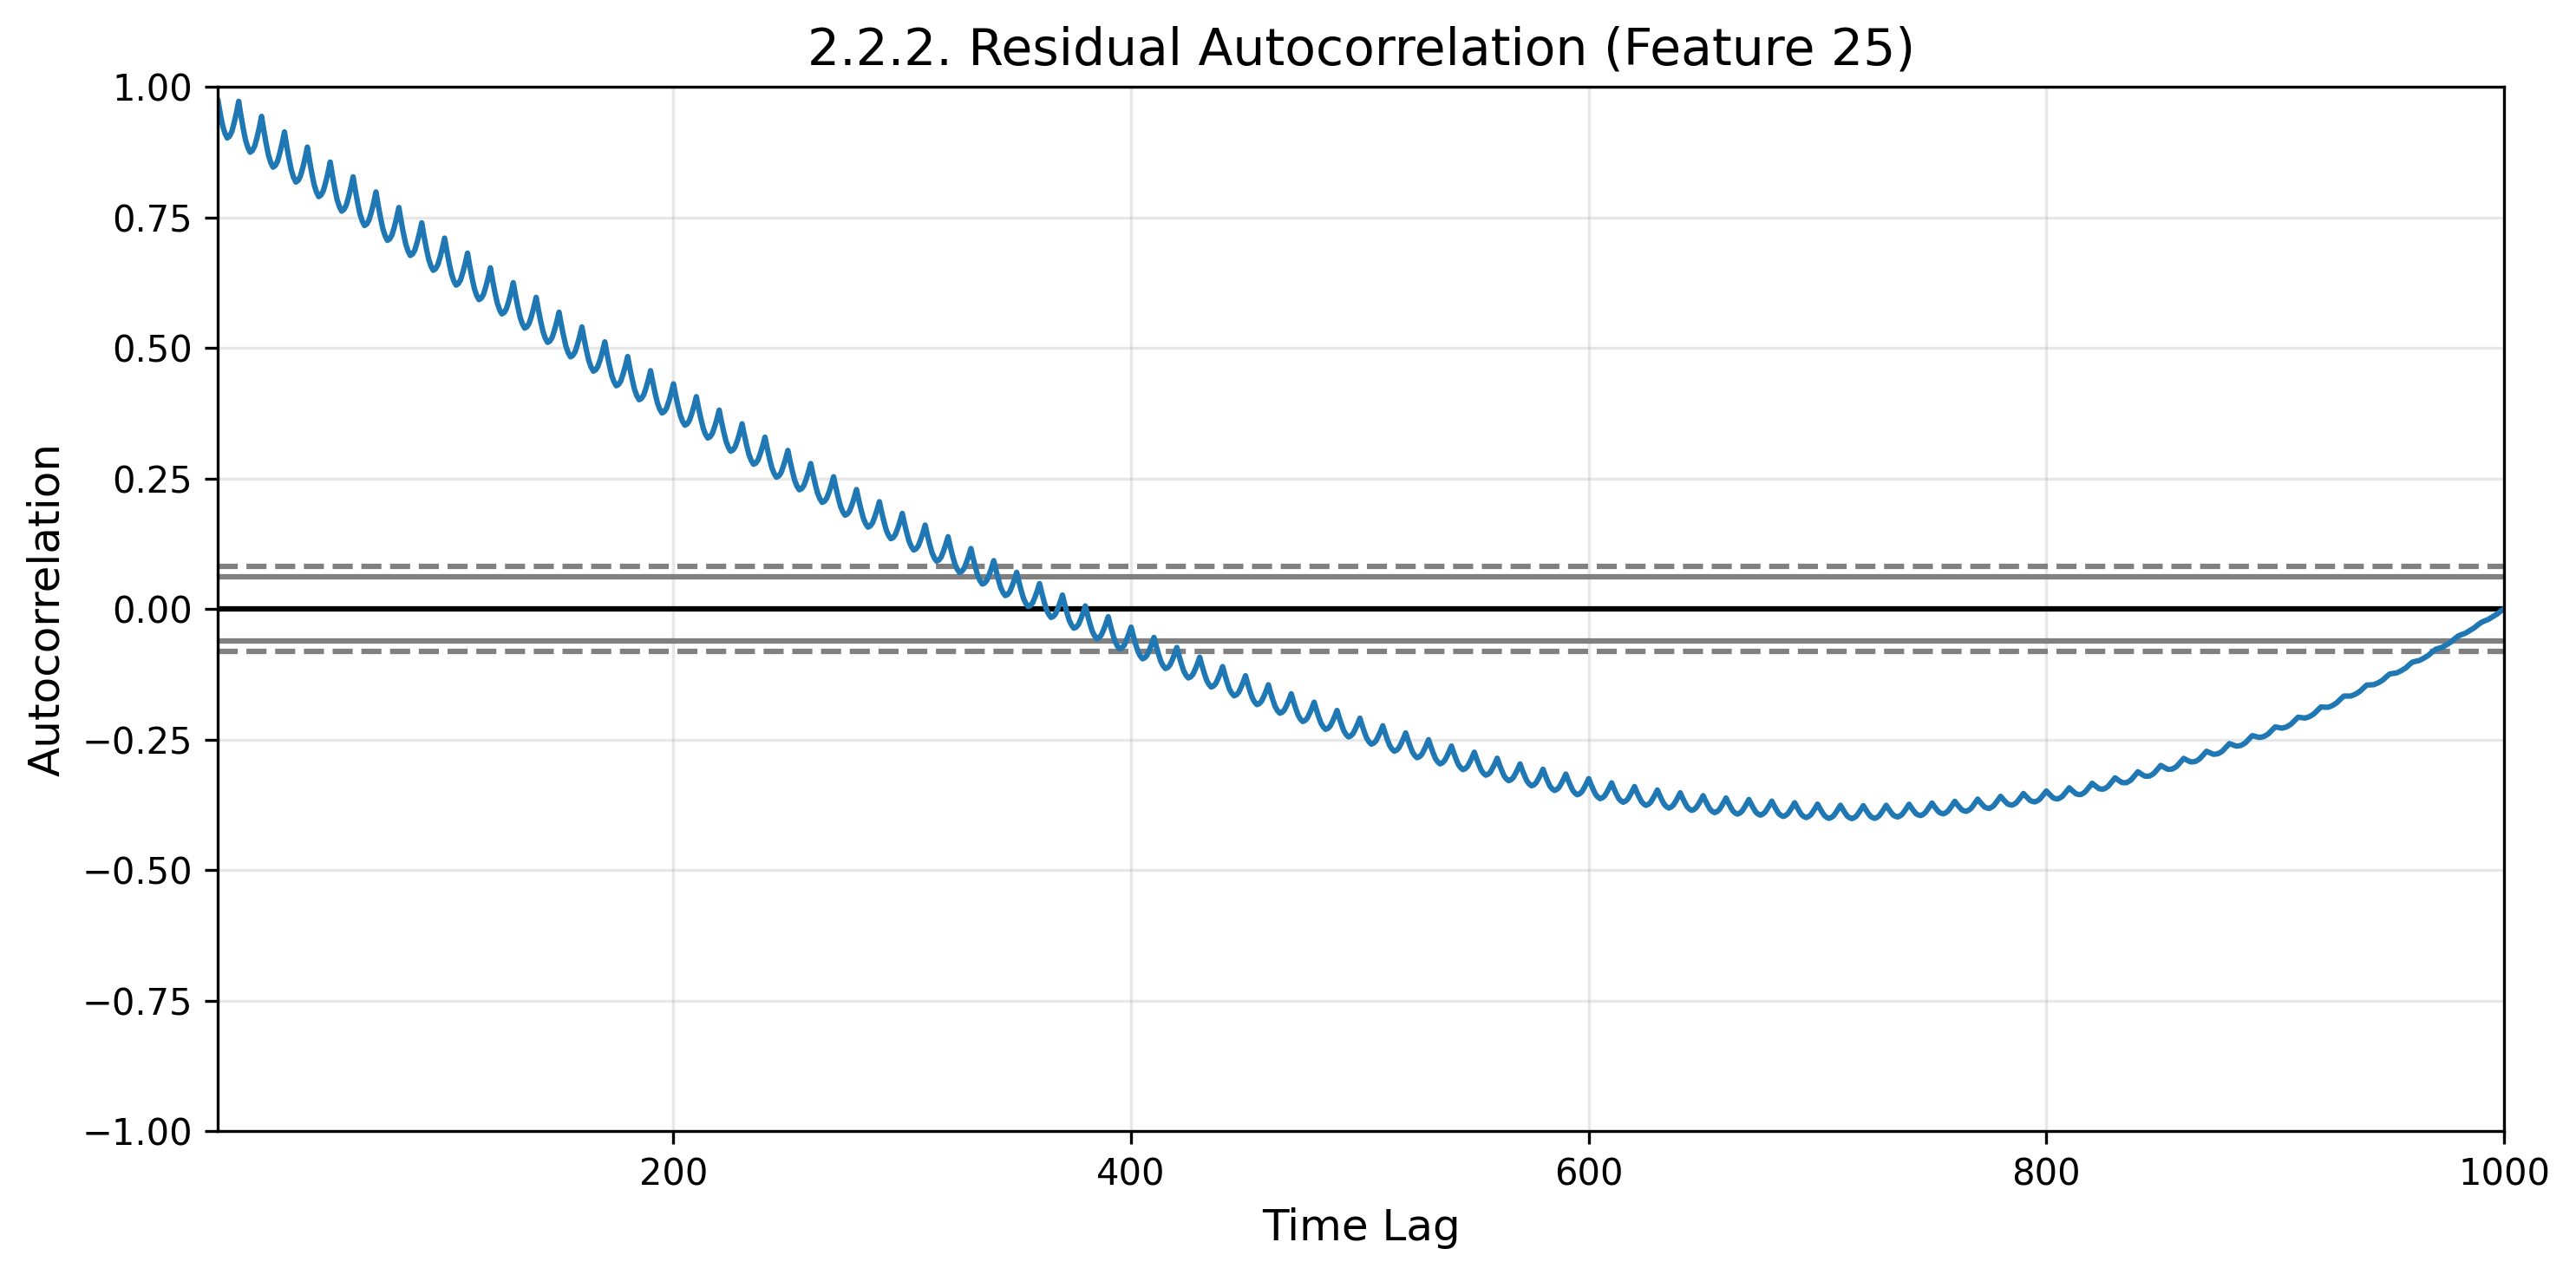

✅ Grafico Autocorrelazione generato.


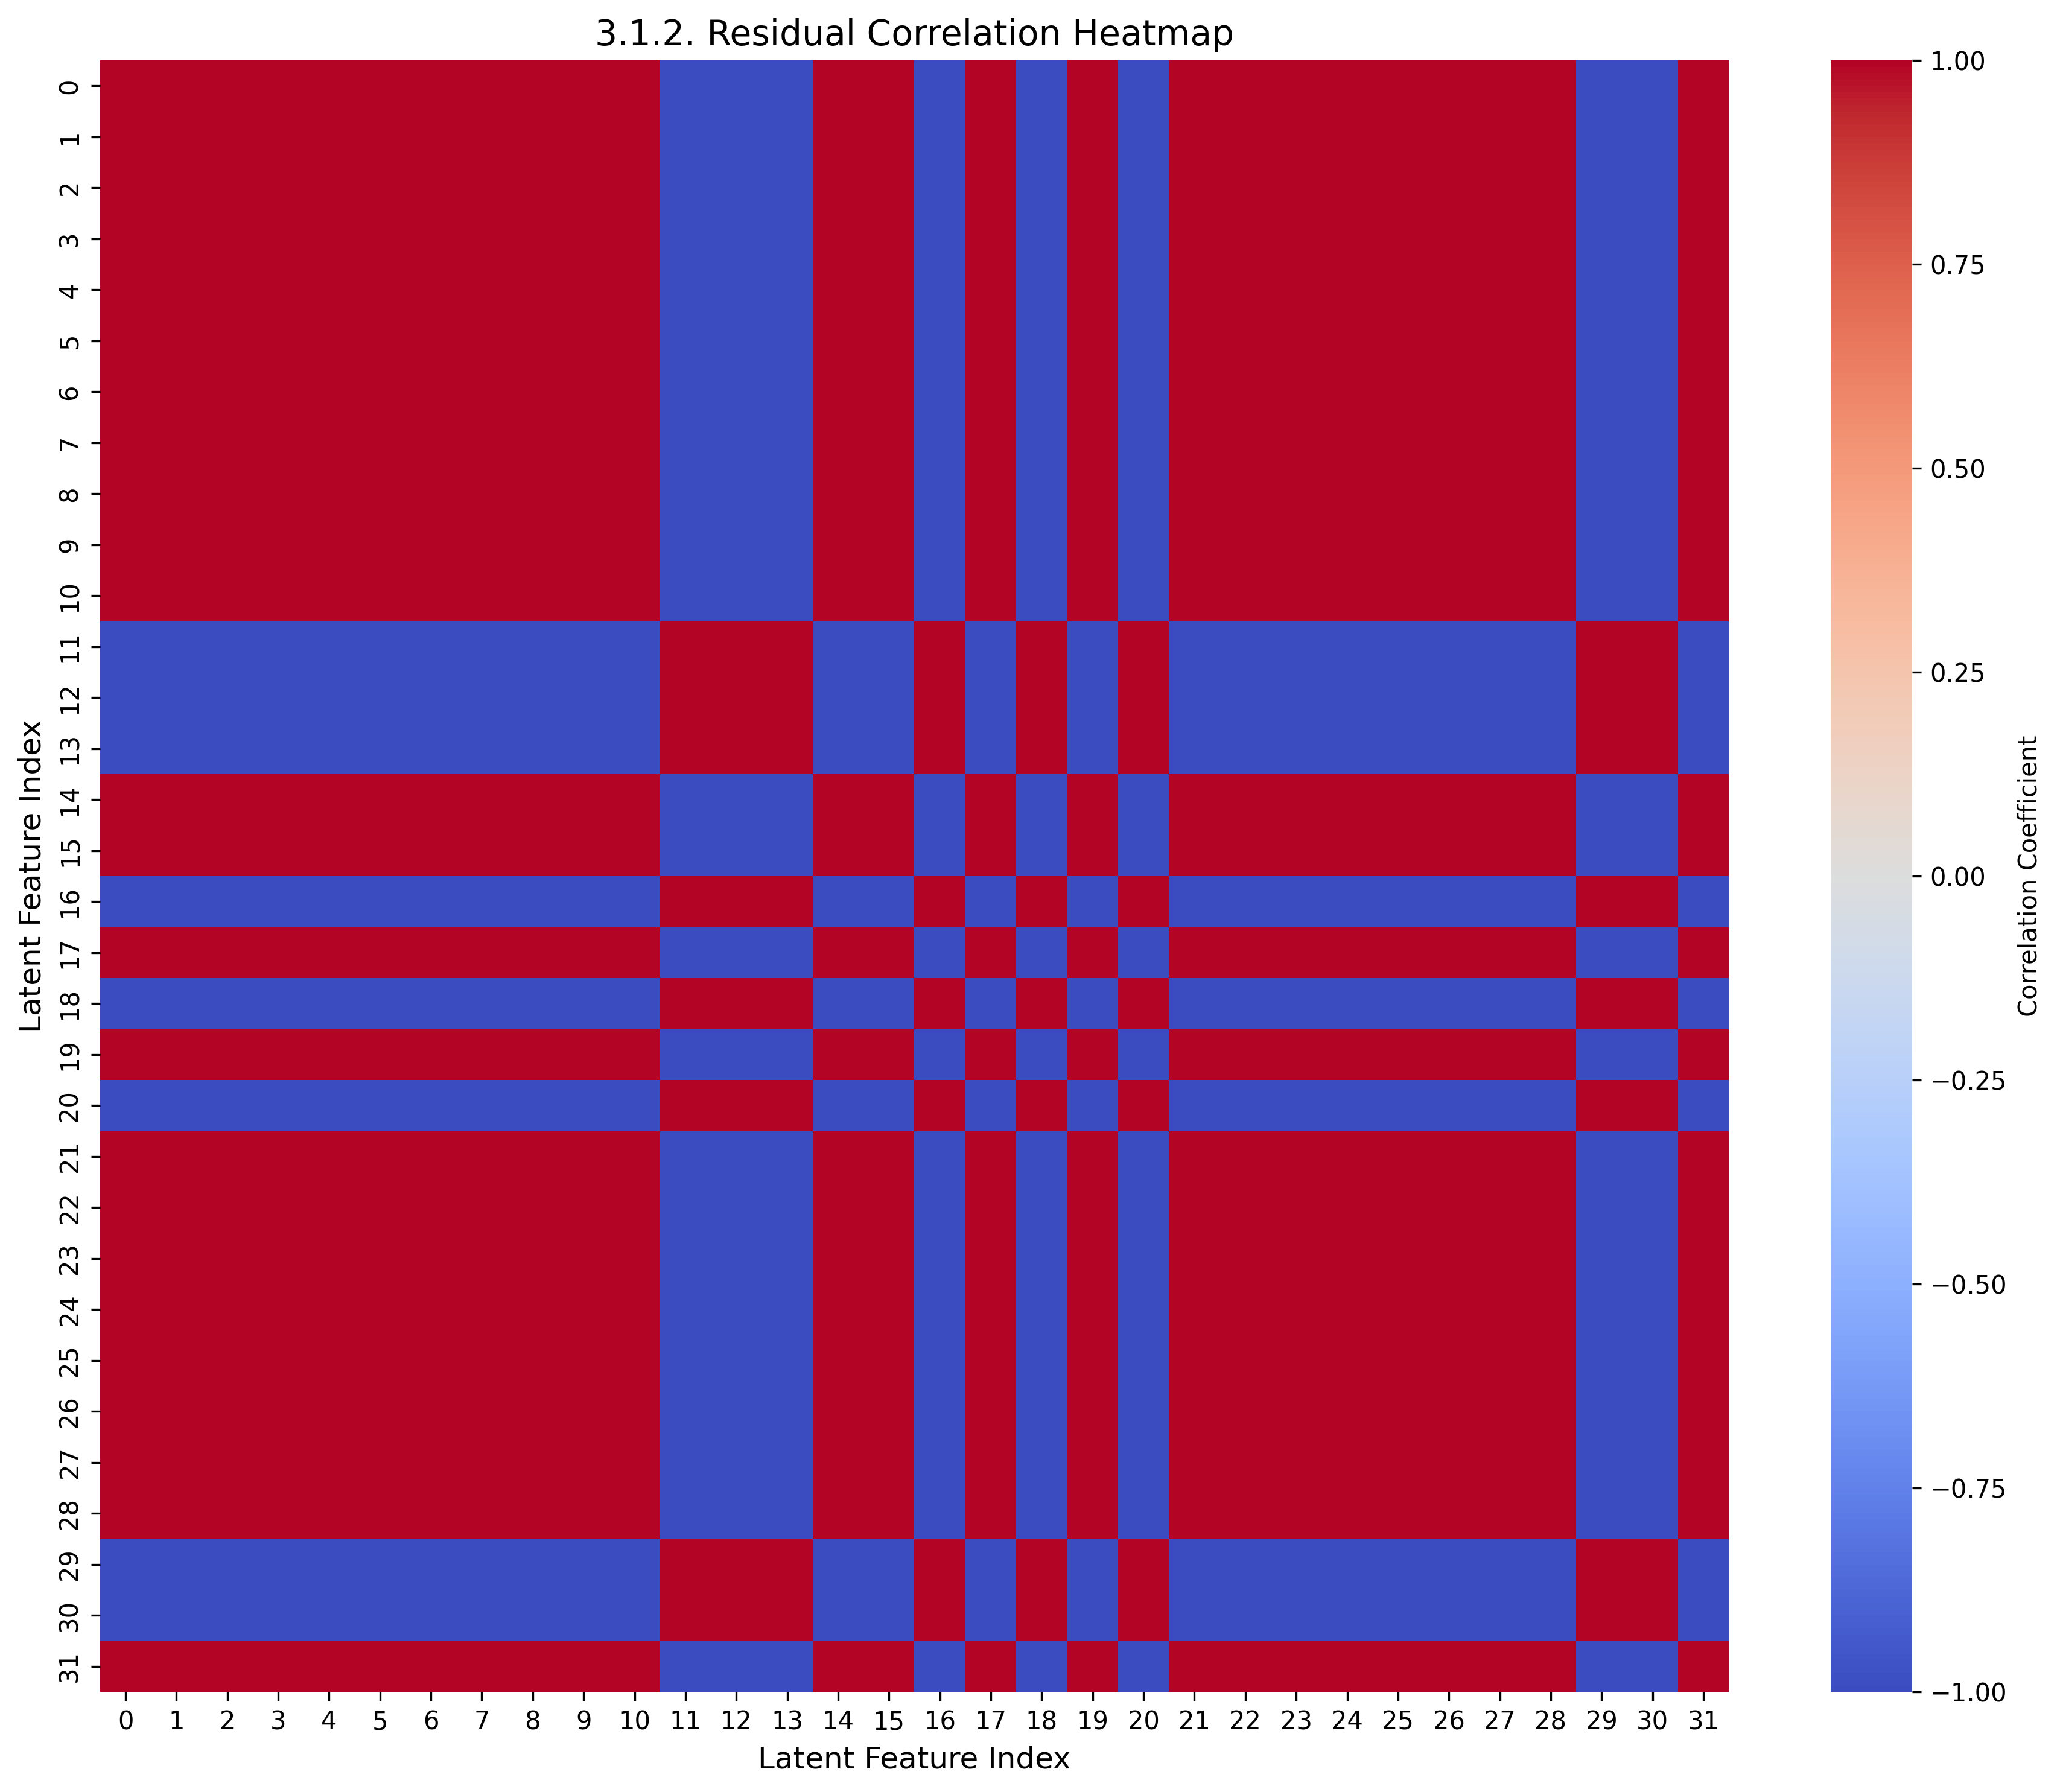

✅ Heatmap generata.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("🎨 Generazione dei grafici 'Mancanti' per completare l'Indice...")

# ==============================================================================
# COMPLETAMENTO SEZIONE II: AUTOCORRELAZIONE (Punto 2.2.2)
# ==============================================================================
# L'autocorrelazione ci dice: "Se ho sbagliato ora, sbaglierò anche tra un secondo?"
# Prendiamo la feature attiva migliore
if len(active_indices) > 0:
    best_feat = active_indices[np.argmax(variances[active_indices])]
    
    # Calcoliamo l'errore su questa feature nel tempo
    res_best = residuals[:, best_feat]
    
    plt.figure(figsize=(10, 5), dpi=300)
    pd.plotting.autocorrelation_plot(res_best[:1000]) # Plot sui primi 1000 step
    plt.title(f'2.2.2. Residual Autocorrelation (Feature {best_feat})', fontsize=14)
    plt.xlabel('Time Lag', fontsize=12)
    plt.ylabel('Autocorrelation', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('Eval_2_2_Autocorrelation.jpg', dpi=300)
    plt.show()
    print("✅ Grafico Autocorrelazione generato.")
else:
    print("⚠️ Nessuna feature attiva per l'autocorrelazione.")

# ==============================================================================
# COMPLETAMENTO SEZIONE III: HEATMAP CORRELAZIONE (Punto 3.1.2)
# ==============================================================================
# Vediamo se gli errori delle varie feature sono collegati tra loro
plt.figure(figsize=(12, 10), dpi=300)

# Calcoliamo la matrice di correlazione dei residui
# (Trasponiamo per avere (Features x Samples))
corr_matrix = np.corrcoef(residuals.T)

sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, 
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title('3.1.2. Residual Correlation Heatmap', fontsize=14)
plt.xlabel('Latent Feature Index', fontsize=12)
plt.ylabel('Latent Feature Index', fontsize=12)
plt.tight_layout()
plt.savefig('Eval_3_1_Heatmap.jpg', dpi=300)
plt.show()

print("✅ Heatmap generata.")